# Анализ продаж и поиск точек роста прибыли кофейни

**Задача**

В ноябре 2025 года дневная выручка кофейни снизилась примерно на 35%. Цель проекта — определить причины снижения выручки и найти способы увеличения прибыли на основе данных о продажах.

**Данные**

Для анализа использовались данные POS-системы кофейни за период с 2 января по 30 ноября 2025 года: транзакции, состав чеков, товары, цены и время продаж. Позиции меню были дополнительно объединены в товарные категории для анализа.

**Что было исследовано**
- Динамика выручки, количества чеков и среднего чека.
- Распределение посещаемости по дням недели и часам.
- Структура продаж и популярность товарных категорий.
- Товары, которые клиенты чаще всего покупают вместе.
- Динамика продаж specialty и non-specialty позиций.
- Маржинальность отдельных позиций с учетом себестоимости.
- Цены основных конкурентов.

**Основные выводы**
- Падение выручки в ноябре связано преимущественно со снижением количества чеков, а не среднего чека.
- Наиболее высокая посещаемость приходится на период с 10:00 до 14:00 и выходные дни.
- Выручка заметно увеличивается в дни проведения мероприятий, что подтверждает потенциал событий как инструмента привлечения трафика.
- Выявлены устойчивые сочетания товаров, которые можно использовать для формирования комбо и увеличения среднего чека.
- Для ряда позиций обнаружена низкая маржинальность и потенциал повышения цены.
- Сравнение с конкурентами показало, что часть ключевых напитков кофейни продается ниже среднего рыночного уровня.

**Рекомендации**

По результатам анализа предложены четыре направления роста прибыли: пересмотр цен низкомаржинальных и недооцененных позиций, формирование комбо для увеличения среднего чека, стимулирование спроса в часы низкой загрузки и регулярное проведение мероприятий для привлечения посетителей.

**Следующий этап**

Для более точной оценки прибыльности рекомендовано дополнить анализ данными о постоянных и переменных расходах, начать фиксировать канал потребления («здесь» / «с собой») и собирать данные для сегментации клиентской аудитории.

# Загрузка данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import chardet
import re
import math
import unicodedata
from pathlib import Path
from difflib import get_close_matches
from itertools import combinations
from collections import Counter

In [2]:
transactions = pd.read_csv(
    './data/coffee_shop/transactions.csv',
    sep=';',
    encoding='windows-1252',
    engine='python'
)

In [3]:
costs = pd.read_csv(
    './data/coffee_shop/costs.csv',
    sep=';',
    encoding='windows-1252',
    engine='python'
)

In [4]:
ingredients = pd.read_csv(
    './data/coffee_shop/ingredients.csv',
    sep=';',
    encoding='windows-1252',
    engine='python'
)

In [5]:
position_names = pd.read_csv(
    './data/coffee_shop/position_names.csv',
    sep=','
)

# Предобработка данных

## Предобработка данных transactions

In [6]:
# удаляем пустой столбец 'Unnamed: 11'
if 'Unnamed: 11' in transactions.columns:
    transactions = transactions.drop(columns=['Unnamed: 11'])

In [7]:
# удаляем столбец 'ime blagajne', т.к. там только одно значение 'Blagajna 1'
transactions = transactions.drop(columns=['ime blagajne'])

In [8]:
# удаляем столбец 'ime prodavac', т.к. там только одно значение, не имеющее бизнес-значение
transactions = transactions.drop(columns=['prodavac'])

In [9]:
# удаляем 2 последние суммирующие строки в выгрузке (в них пустое все, кроме broj racuna)
transactions = transactions[~transactions['vreme izdavanja'].isna()].copy()
transactions = transactions.reset_index(drop=True)

In [10]:
# переводим дату и время транзакции в тип данных datetime
transactions['vreme izdavanja'] = pd.to_datetime(
    transactions['vreme izdavanja'],
    format='%d.%m.%Y %H:%M',
    errors='coerce' # если вдруг есть битые значения
)

In [11]:
# переводим сумму чека в числовой тип данных
# формат: "1.010,000" -> 1010.000
col_amount = 'iznos racuna [rsd]'
transactions[col_amount] = (
    transactions[col_amount]
    .astype(str)
    .str.replace('.', '', regex=False) # убираем разделитель тысяч
    .str.replace(',', '.', regex=False) # делаем десятичный разделитель точкой
    .astype(float)
)

In [12]:
# убираем из способа оплаты сумму (т.к. она есть в другом столбце)
transactions['nacin placanja'] = (
    transactions['nacin placanja']
        .astype(str)
        .str.split('=')
        .str[0]
        .str.strip()
)

In [13]:
# в столбце 'pfr broj' оставляем только номер чека (убираем общую для всех строк часть)
transactions['pfr broj'] = transactions['pfr broj'].str.replace('LB4U2HQF-LB4U2HQF-', '', regex=False)
# приводим к числовому типу данных
transactions['pfr broj'] = pd.to_numeric(transactions['pfr broj'], errors='coerce').astype('Int64')

In [14]:
# удаляем транзакции с возвратами (все строки, где в столбце 's' содержатся значения 'D' или 'X []')
transactions = transactions[
    ~transactions['s'].astype(str).str.contains(r'[XD]')
]

# удаляем столбец 's' (так как там теперь только значения '!')
transactions = transactions.drop(columns=['s'])

In [15]:
# удаляем столбец 'vrsta i tip' (так как там теперь только значения 'Promet Prodaja [PP]')
transactions = transactions.drop(columns=['vrsta i tip'])

In [16]:
# удаляем столбец 'broj racuna' (так как есть столбец 'pfr broj')
transactions = transactions.drop(columns=['broj racuna'])

In [17]:
# вывод всех чеков, когда оплата проходила через юр.лицо (знакомство с данными)
transactions[transactions['stranka'].notna()]

,vreme izdavanja,iznos racuna [rsd],stavke racuna,nacin placanja,stranka,pfr broj
115,2025-11-26 18:35:00,1230.0,"2,00 x Cappuccino (230,000) = 460,00 + 1,00 x...",Platna kartica,Tramontana IMC,10498
825,2025-11-04 19:23:00,1160.0,"2,00 x Cappuccino (230,000) = 460,00 + 1,00 x...",Platna kartica,Tramontana IMC,9788
1081,2025-10-28 18:25:00,1000.0,"2,00 x Cappuccino (230,000) = 460,00 + 2,00 x...",Platna kartica,Tramontana IMC,9531
1490,2025-10-18 13:07:00,930.0,"1,00 x Zova (200,000) = 200,00 + 1,00 x Naran...",Platna kartica,Tramontana IMC,9122
2007,2025-10-04 12:19:00,980.0,"1,00 x Brownies (250,000) = 250,00 + 2,00 x C...",Platna kartica,Tramontana IMC,8605
2186,2025-09-28 11:55:00,810.0,"1,00 x Brownies (250,000) = 250,00 + 2,00 x C...",Platna kartica,Tramontana IMC,8426
2203,2025-09-27 17:58:00,1120.0,"1,00 x Cappuccino (230,000) = 230,00 + 1,00 x...",Platna kartica,Tramontana IMC,8409
4434,2025-03-11 10:45:00,750.0,"2,00 x Kroasan (150,000) = 300,00 + 1,00 x Co...",Platna kartica,ServiceDesk i SIAM doo,1734
5257,2025-01-17 16:10:00,201.6,"1,00 x Doppio (201,600) = 201,60 [-10,00%]",Platna kartica,Komšije,633
5399,2025-01-31 14:10:00,3350.0,"1,00 x Kenya Muranga g (2.950,000) = 2.950,00 ...",Platna kartica,ServiceDesk i SIAM doo,917


In [18]:
# переименуем столбцы
transactions = transactions.rename(columns={
    'vreme izdavanja': 'datetime',
    'iznos racuna [rsd]': 'total',
    'stavke racuna': 'positions',
    'nacin placanja': 'payment_method',
    'stranka': 'organization',
    'pfr broj': 'check_number'
})

In [19]:
# проверка
transactions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10234 entries, 0 to 10233
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   datetime        10234 non-null  datetime64[ns]
 1   total           10234 non-null  float64       
 2   positions       10234 non-null  object        
 3   payment_method  10234 non-null  object        
 4   organization    10 non-null     object        
 5   check_number    10234 non-null  Int64         
dtypes: Int64(1), datetime64[ns](1), float64(1), object(3)
memory usage: 569.7+ KB


In [20]:
# проверка
transactions.head()

,datetime,total,positions,payment_method,organization,check_number
0,2025-09-06 14:58:00,290.0,"1,00 x Espresso Freddo (290,000) = 290,00",Gotovina,NaN,7540
1,2025-11-30 15:09:00,590.0,"1,00 x filter batch brew tasty (290,000) = 290...",Platna kartica,NaN,10613
2,2025-11-30 15:04:00,400.0,"1,00 x V60-2 (400,000) = 400,00",Gotovina,NaN,10612
3,2025-11-30 15:00:00,810.0,"2,00 x Flat white (300,000) = 600,00 + 1,00 x...",Platna kartica,NaN,10611
4,2025-11-30 14:58:00,1010.0,"1,00 x Macha Latte (350,000) = 350,00 + 1,00 ...",Gotovina,NaN,10610


### Разбиение по позициям в чеке

In [21]:
positions = (
    transactions
        .assign(position_str = transactions['positions'].str.split(r'\s*\+\s*'))
        .explode('position_str') # одна позиция чека = одна строка
)

# на всякий случай убираем пробелы по краям
positions['position_str'] = positions['position_str'].str.strip()

In [22]:
pattern = r'''
    ^\s*
    (\d+,\d+)          # 1. количество, напр. 1,00
    \s*x\s*
    (.+?)              # 2. название товара (жадно, но до скобки)
    \s*\(
        ([\d\.,]+)     # 3. цена за единицу, напр. 201,600
    \)\s*=\s*
        ([\d\.,]+)     # 4. сумма по позиции, напр. 201,60
    (?:\s*\[([^\]]+)\])?  # 5. опциональная скидка в квадратных скобках
    \s*$
'''

cols = ['qty', 'name', 'unit_price', 'subtotal', 'discount']

positions[cols] = positions['position_str'].str.extract(
    pattern,
    expand=True,
    flags=re.VERBOSE
)

In [23]:
# удаляем столбец 'positions' (так как есть столбец 'position_str')
positions = positions.drop(columns=['positions'])

In [24]:
# приведение к числовому типу данных
positions['qty'] = (positions['qty'].astype(str).str.replace(',', '.', regex=False).astype(float).astype(int))
positions['unit_price'] = (positions['unit_price'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float))
positions['subtotal'] = (positions['subtotal'].astype(str).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float))
positions['discount'] = (positions['discount'].str.extract(r'(-?\d+,\d+)\s*%', expand=False).str.replace('.', '', regex=False).str.replace(',', '.', regex=False).astype(float))

In [25]:
positions['discount'] = 1 - (positions['discount'].abs() / 100)

In [26]:
positions['discount'] = positions['discount'].fillna(1.0)

In [27]:
# восстанавливаем цену до скидки (скидки применялись без какой-то системы скидок, непоследовательно)
positions['unit_price'] = positions['unit_price'] / positions['discount']
positions['unit_price'] = positions['unit_price'].round(0)

# пересчитываем сумму позиции до скидки
positions['subtotal'] = positions['subtotal'] / positions['discount']
positions['subtotal'] = positions['subtotal'].round(0)

In [28]:
# проверка
positions.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17164 entries, 0 to 10233
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   datetime        17164 non-null  datetime64[ns]
 1   total           17164 non-null  float64       
 2   payment_method  17164 non-null  object        
 3   organization    26 non-null     object        
 4   check_number    17164 non-null  Int64         
 5   position_str    17164 non-null  object        
 6   qty             17164 non-null  int64         
 7   name            17164 non-null  object        
 8   unit_price      17164 non-null  float64       
 9   subtotal        17164 non-null  float64       
 10  discount        17164 non-null  float64       
dtypes: Int64(1), datetime64[ns](1), float64(4), int64(1), object(4)
memory usage: 1.6+ MB


In [29]:
# проверка
positions.head()

,datetime,total,payment_method,organization,check_number,position_str,qty,name,unit_price,subtotal,discount
0,2025-09-06 14:58:00,290.0,Gotovina,NaN,7540,"1,00 x Espresso Freddo (290,000) = 290,00",1,Espresso Freddo,290.0,290.0,1.0
1,2025-11-30 15:09:00,590.0,Platna kartica,NaN,10613,"1,00 x filter batch brew tasty (290,000) = 290,00",1,filter batch brew tasty,290.0,290.0,1.0
1,2025-11-30 15:09:00,590.0,Platna kartica,NaN,10613,"1,00 x Flat white (300,000) = 300,00",1,Flat white,300.0,300.0,1.0
2,2025-11-30 15:04:00,400.0,Gotovina,NaN,10612,"1,00 x V60-2 (400,000) = 400,00",1,V60-2,400.0,400.0,1.0
3,2025-11-30 15:00:00,810.0,Platna kartica,NaN,10611,"2,00 x Flat white (300,000) = 600,00",2,Flat white,300.0,600.0,1.0


## Предобработка данных ingredients

In [30]:
# переименование столбцов
ingredients = ingredients.rename(columns={
    'prodajni artikal': 'sale_item',
    'sastavnica': 'component',
    'prodajna grupa': 'system_group',
    'bruto cena [rsd]': 'gross_price_in_coffee_shop',
    'nabavna cena [rsd]': 'purchase_price',
    'ruc [rsd] (marža %)': 'margin',
    'popust': 'discount',
    'aktivno': 'active',
})

In [31]:
# приведение к булевому типу данных
ingredients["discount"] = ingredients["discount"] == "Da"
ingredients["active"] = ingredients["active"] == "Da"

In [32]:
# приведение к числовому типу данных

# функция очистки чисел
def to_number(series):
    return (
        series.astype(str)
        .str.replace(".", "", regex=False)      # убираем точки-разделители тысяч
        .str.replace(",", ".", regex=False)     # запятую меняем на точку
        .astype(float)
    )

ingredients["gross_price_in_coffee_shop"] = to_number(ingredients["gross_price_in_coffee_shop"])
ingredients["purchase_price"] = to_number(ingredients["purchase_price"])

In [33]:
# преобразование столбца 

# достаём сумму до скобок и чистим
def clean_margin_amount(x):
    s = str(x).split('(')[0].strip()          # всё до "("
    s = re.sub(r'[^0-9\.,]', '', s)           # оставляем только цифры, . и ,
    
    # если точек больше одной (типа "2.389.93"), считаем, что последние 2–3 знака после последней точки — дробная часть
    if s.count('.') > 1:
        parts = s.split('.')
        s = ''.join(parts[:-1]) + '.' + parts[-1]

    # если и запятая, и точка: точка = разделитель тысяч, запятая = десятичная
    if ',' in s and '.' in s:
        s = s.replace('.', '')
        s = s.replace(',', '.')
    else:
        s = s.replace(',', '.') # если только запятая — делаем её десятичной

    return s

# достаём процент из скобок и чистим
def clean_margin_percent(x):
    m = re.search(r'\(([^%]+)%\)', str(x))
    if not m:
        return None
    s = m.group(1).strip()
    s = re.sub(r'[^0-9,\.]', '', s)
    s = s.replace('.', '')        # точка как разделитель тысяч
    s = s.replace(',', '.')       # запятая как десятичная
    return s

# применяем к датафрейму
amount_clean = ingredients["margin"].apply(clean_margin_amount)
percent_clean = ingredients["margin"].apply(clean_margin_percent)

ingredients["margin"] = pd.to_numeric(amount_clean, errors="coerce")
ingredients["margin_percent"] = pd.to_numeric(percent_clean, errors="coerce")

In [34]:
ingredients.drop(columns=["Unnamed: 8"], inplace=True)

In [35]:
ingredients[ingredients['purchase_price'] < 10]

,sale_item,component,system_group,gross_price_in_coffee_shop,purchase_price,margin,discount,active,margin_percent
51,cimet rolnice,NaN,Dezert,250.0,0.0000,250.00,True,True,0.00
136,Kuvano Vino,NaN,Topli napici,300.0,0.0000,300.00,True,True,0.00
143,Limunada,"0,03 Kilogram Limun",Bezalkoholna pica,190.0,7.6307,182.37,True,True,2389.93
156,Marshmellos,1 Komad Marshmellos,Dodaci,30.0,0.0000,30.00,True,True,0.00
180,rod kolaci,NaN,Dezert,100.0,0.0000,100.00,True,True,0.00
183,sirup Coko Cookie,"0,015 Litar Sirup Coko Cookie",Dodaci,100.0,0.0257,99.97,True,True,388785.65
248,Višnja,"0,005 Litar Sirup od višnje",Bezalkoholna pica,200.0,5.3614,194.64,True,True,3630.35


In [36]:
# ручные исправления в данных

# cimet rolnice - закупаются за 180 (узнала от владелицы, поправляю вручную)
ingredients.loc[ingredients['sale_item'] == "cimet rolnice", 'purchase_price'] = 180

# маршмеллоу не было и не будет, удаляем (узнала от владелицы, поправляю вручную)
ingredients = ingredients[ingredients['sale_item'] != "Marshmellos"]
ingredients.reset_index(drop=True, inplace=True)

# сироп вишневый поправили в системе (поправляю вручную)
mask_visnja = ingredients['sale_item'] == "Višnja"
ingredients.loc[mask_visnja, 'component'] = "0,05 Litar Sirup od višnje"
ingredients.loc[mask_visnja, 'system_group'] = "Dodaci"
ingredients.loc[mask_visnja, 'purchase_price'] = 53.614
ingredients.loc[mask_visnja, 'margin'] = 146.39
ingredients.loc[mask_visnja, 'margin_percent'] = 273.03

# шоколадный сироп тоже поправили в системе (поправляю вручную)
mask_coko = ingredients['sale_item'] == "sirup Coko Cookie"
ingredients.loc[mask_coko, 'component'] = "0,02 Litar Sirup Coko Cookie"
ingredients.loc[mask_coko, 'purchase_price'] = 48.9714
ingredients.loc[mask_coko, 'margin'] = 51.03
ingredients.loc[mask_coko, 'margin_percent'] = 104.20

# Kuvano Vino - все расходы на него вписаны в папочку у бухгалтера, одноразово было на маркете
# rod kilaci - все эти сладости в систему не вносили, была одноразовая акция (владелица предложила не учитывать при анализе)

In [37]:
# проверка
ingredients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   sale_item                   255 non-null    object 
 1   component                   252 non-null    object 
 2   system_group                255 non-null    object 
 3   gross_price_in_coffee_shop  255 non-null    float64
 4   purchase_price              255 non-null    float64
 5   margin                      255 non-null    float64
 6   discount                    255 non-null    bool   
 7   active                      255 non-null    bool   
 8   margin_percent              255 non-null    float64
dtypes: bool(2), float64(4), object(3)
memory usage: 14.6+ KB


In [38]:
# проверка
ingredients.head()

,sale_item,component,system_group,gross_price_in_coffee_shop,purchase_price,margin,discount,active,margin_percent
0,1600,250 Gram Filter coffee TASTY,TASTY,1600.0,1432.5,167.5,True,True,11.69
1,1650,250 Gram Filter coffee TASTY,TASTY,1650.0,1432.5,217.5,True,True,15.18
2,1700,250 Gram Filter coffee TASTY,TASTY,1700.0,1432.5,267.5,True,True,18.67
3,1750,250 Gram Filter coffee TASTY,TASTY,1750.0,1432.5,317.5,True,True,22.16
4,1800,250 Gram Filter coffee TASTY,TASTY,1800.0,1432.5,367.5,True,True,25.65


## Предобработка данных positions_names

In [39]:
# переименование столбцов
position_names = position_names.rename(columns={
    'Позиция': 'position_name',
    'Тип напитка': 'group',
    'Decaf': 'is_decaf',
    'Обжарщик': 'roaster',
    'Молоко': 'type_of_milk',
    'Размер': 'size',
    'Спешалти': 'specialty',
    'Комментарий': 'comment'
})

# приводим к булевому типу: Yes ставится True, остальное становится False
position_names['is_decaf'] = position_names['is_decaf'].eq("Yes")

# приводим к булевому типу
position_names['specialty'] = position_names['specialty'].map({
    'Да': True,
    'Нет': False
})

# заполняем пустые значения типом молока "cow"
position_names['type_of_milk'] = position_names['type_of_milk'].fillna("cow")

# заполняем пустые значения размером "standard"
position_names['size'] = position_names['size'].fillna("standard")

# удаляем столбец "comment" (не имеет бизнес-ценности)
position_names = position_names.drop(columns=["comment"])

In [40]:
# проверка
position_names.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 313 entries, 0 to 312
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   position_name  313 non-null    object
 1   group          313 non-null    object
 2   is_decaf       313 non-null    bool  
 3   roaster        132 non-null    object
 4   type_of_milk   313 non-null    object
 5   size           313 non-null    object
 6   specialty      313 non-null    bool  
dtypes: bool(2), object(5)
memory usage: 13.0+ KB


In [41]:
# проверка
position_names.head()

,position_name,group,is_decaf,roaster,type_of_milk,size,specialty
0,extra shot,Additions,False,NaN,cow,standard,False
1,sirup vanila,Additions,False,NaN,cow,standard,False
2,sirup karamela,Additions,False,NaN,cow,standard,False
3,sirup Coko Cookie,Additions,False,NaN,cow,standard,False
4,bundeva sirup,Additions,False,NaN,cow,standard,False


### Дополняем данные датафрейма positions

In [42]:
# дополняем positions данными из ingredients

# создаём колонку system_group (пока пустую)
positions["system_group"] = None

# мержим данные
positions = positions.merge(
    ingredients[["sale_item", "system_group"]],
    how="left",
    left_on="name",
    right_on="sale_item")

# удаляем ненужные колонки
positions.drop(columns=["system_group_x", "sale_item"], inplace=True)

# переименовываем колонку
positions.rename(columns={"system_group_y": "system_group"}, inplace=True)

In [43]:
# дополняем positions данными из positions_names

# создаём копию и переименовываем поле
pos_names = position_names.copy()
pos_names = pos_names.rename(columns={'position_name': 'name'})

# теперь удаляем ненужную колонку, если ещё нужно
# pos_names = pos_names.drop(columns=['comment'])  # если ты ещё не удалял

# объединяем по колонке 'name'
positions = positions.merge(
    pos_names,
    on='name',
    how='left'
)

In [44]:
# проверка
positions.head()

,datetime,total,payment_method,organization,check_number,position_str,qty,name,unit_price,subtotal,discount,system_group,group,is_decaf,roaster,type_of_milk,size,specialty
0,2025-09-06 14:58:00,290.0,Gotovina,NaN,7540,"1,00 x Espresso Freddo (290,000) = 290,00",1,Espresso Freddo,290.0,290.0,1.0,Cold Coffee,Espresso Freddo,False,NaN,cow,standard,False
1,2025-11-30 15:09:00,590.0,Platna kartica,NaN,10613,"1,00 x filter batch brew tasty (290,000) = 290,00",1,filter batch brew tasty,290.0,290.0,1.0,Filter,Filter Batch Brew,False,Tasty,cow,standard,True
2,2025-11-30 15:09:00,590.0,Platna kartica,NaN,10613,"1,00 x Flat white (300,000) = 300,00",1,Flat white,300.0,300.0,1.0,Topli napici,Flat white,False,NaN,cow,standard,False
3,2025-11-30 15:04:00,400.0,Gotovina,NaN,10612,"1,00 x V60-2 (400,000) = 400,00",1,V60-2,400.0,400.0,1.0,73 Roasters,V60,False,Indijana,cow,standard,True
4,2025-11-30 15:00:00,810.0,Platna kartica,NaN,10611,"2,00 x Flat white (300,000) = 600,00",2,Flat white,300.0,600.0,1.0,Topli napici,Flat white,False,NaN,cow,standard,False


## Предобработка данных costs

In [45]:
# переименование столбцов
costs = costs.rename(columns={
    'br prijema': 'receipt_number',
    'broj dokumenta': 'document_number',
    'datum prijema': 'date_of_receipt',
    'dobavljac': 'supplier',
    'stavke': 'items',
    'neto vrednost [rsd]': 'net_worth',
    'pdv vrednost [rsd]': 'VAT_value',
    'bruto vrednost [rsd]': 'gross_value',
    'placeno [rsd]': 'paid',
    'za placanje [rsd]': 'for_payment',
    'datum/br racuna': 'date/bill_number',
    'valuta placanja': 'payment_currency',
    'aktivno': 'active'
})

In [46]:
def to_number(series):
    s = (
        series.astype(str)
        .str.strip()
        .str.replace(" ", "", regex=False)   # убираем пробелы
        .str.replace(".", "", regex=False)   # точки-разделители тысяч
        .str.replace(",", ".", regex=False)  # запятая → точка
    )
    return pd.to_numeric(s, errors="coerce")

# преобразование числовых колонок
numeric_cols = ["id", "net_worth", "VAT_value", "gross_value", "paid", "for_payment"]
for col in numeric_cols:
    if col in costs.columns:
        costs[col] = to_number(costs[col])

# преобразование дат
costs["date_of_receipt"] = (
    costs["date_of_receipt"]
    .astype(str)
    .str.strip()
)
costs["date_of_receipt"] = pd.to_datetime(
    costs["date_of_receipt"],
    dayfirst=True,
    errors="coerce"
)
cutoff_date = pd.to_datetime("01.12.2025", dayfirst=True)
costs = costs[costs["date_of_receipt"] < cutoff_date]

# преобразование active в bool
costs["active"] = costs["active"].astype(str).str.strip().eq("Da")

# разделяем date/bill_number
bill = costs["date/bill_number"].astype(str).str.extract(
    r"(?P<bill_date>\d{2}\.\d{2}\.\d{4})\s*(?P<bill_number>.*)"
)
costs["bill_date"] = pd.to_datetime(bill["bill_date"], dayfirst=True, errors="coerce")
costs["bill_number"] = bill["bill_number"].str.strip().replace("", pd.NA)
costs.drop(columns=["date/bill_number"], inplace=True)

In [47]:
# преобразование payment_currency

costs["payment_currency"] = (
    costs["payment_currency"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", " ", regex=True)   # убрать двойные пробелы
        .replace(["None", "none", "", "nan", "NaN"], pd.NA)
)

costs["payment_currency"] = pd.to_datetime(
    costs["payment_currency"],
    dayfirst=True,
    errors="coerce"
)

In [48]:
# оставляем только данные периода анализа
cutoff_date = pd.to_datetime("01.12.2025", dayfirst=True)
costs.drop(costs[costs["date_of_receipt"] >= cutoff_date].index, inplace=True)

In [49]:
costs["id"] = pd.to_numeric(costs["id"], errors="coerce").astype("Int64")

In [50]:
costs['id'].min(), costs['id'].max()

(np.int64(26), np.int64(387))

In [51]:
costs = costs.sort_values(by='id', ascending=True).reset_index(drop=True)

In [52]:
# из колонок с датами оставляем только date_of_receipt + убраем другие лишние колонки
costs.drop(columns=['Unnamed: 14', 'receipt_number', 'payment_currency', 'bill_date', 'bill_number', 'paid'], inplace=True)

In [53]:
# проверяем равенство по каждой строке
mask_diff_pay = costs['for_payment'] != costs['gross_value']

# если различий нет, то оставляем только gross_value
if not mask_diff_pay.any():
    print('Все значения в for_payment и gross_value совпадают → удаляем for_payment')
    costs.drop(columns=['for_payment'], inplace=True)

# если есть различия, выводим строки с различиями
else:
    print('Есть строки, где значения отличаются → выводим строки с различиями')
    display(costs[mask_diff_pay][['gross_value', 'for_payment']].head(20))
    print(f"\nВсего строк с различиями: {mask_diff_pay.sum()}")

Все значения в for_payment и gross_value совпадают → удаляем for_payment


In [54]:
# проверка
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               356 non-null    Int64         
 1   document_number  356 non-null    object        
 2   date_of_receipt  356 non-null    datetime64[ns]
 3   supplier         356 non-null    object        
 4   items            356 non-null    object        
 5   net_worth        356 non-null    float64       
 6   VAT_value        356 non-null    float64       
 7   gross_value      356 non-null    float64       
 8   active           356 non-null    bool          
dtypes: Int64(1), bool(1), datetime64[ns](1), float64(3), object(3)
memory usage: 23.1+ KB


In [55]:
# проверка
costs.head()

,id,document_number,date_of_receipt,supplier,items,net_worth,VAT_value,gross_value,active
0,26,2025-P1-10-000001,2025-01-06,Beograd 1937 doo,"500,00 Gram Colombia Huila Los Patios HB1937 +...",11440.00,0.00,11440.00,True
1,28,2025-P1-10-000002,2025-01-10,METRO,"20,00 Komad Kroasan + 12,00 Litar Mleko",2503.19,72.73,2575.92,True
2,29,2025-P1-10-000003,2025-01-13,METRO,"1,00 Kilogram brašno + 1.000,00 Gram šecer + ...",12088.47,99.86,12188.33,True
3,31,2025-P1-10-000004 2025-P1-15-000001,2025-01-14,Valentina i Karanfil Doo,"200,00 Gram Caramel Hot Chocolate + 200,00 Gr...",3060.00,0.00,3060.00,True
4,32,2025-P1-10-000005,2025-01-14,Indijana doo,"250,00 Gram Colombia El Mirador + 250,00 Gram...",7084.00,132.00,7216.00,True


# Описание данных после предобработки

**Описание данных transactions (транзакции)**
- `datetime` - дата и время транзакции
- `total` - сумма в чеке
- `positions` - позиции в чеке
- `payment_method` - способ оплаты
- `organization` - оплата юр. лицом
- `check_number` - номер чека

**Описание данных positions (транзакции по позициям в чеке)**
- `datetime` - дата и время транзакции
- `total` - сумма в чеке
- `payment_method` - способ оплаты
- `organization` - оплата юр. лицом
- `check_number` - номер чека
- `position_str` - позиции в чеке строкой (как в системе)
- `qty` - количество
- `name` - название позиции в чеке
- `unit_price` - стоимость позиции
- `subtotal` - сумма за одинаковые позиции в чеке
- `discount` - скидка (коэффициент, например, 0.9, если скидка 10%)
- `system_group` - группа в системе

**Описание данных ingredients (ингредиенты)**
- `sale_item` - позиция в чеке
- `component` - состав
- `system_group` - группа в системе
- `gross_price_in_coffee_shop` - цена в кофейне
- `purchase_price` - стоимость покупки
- `margin` - маржинальность (в сербских динарах)
- `discount` - чекбокс о скидке
- `active` - чекбокс об активности позиции
- `margin_percent` - маржинальность (%)

**Описание данных costs (закупки)**
- `id` - системный идентификатор покупки
- `document_number` - номер документа
- `date_of_receipt` - дата покупки
- `supplier` - место покупки
- `items` - купленные товары
- `net_worth` - цена без НДС
- `VAT_value` - НДС
- `gross_value` - цена с НДС

In [56]:
# период анализа
transactions['datetime'].min(), transactions['datetime'].max()

(Timestamp('2025-01-02 10:50:00'), Timestamp('2025-11-30 15:23:00'))

# Исследовательский анализ данных

## Графики корреляций

In [57]:
def correlation_dashboard(df, title="", max_cols=8, sample_size=None):
    """
    Строит в одной ячейке:
    1) Heatmap корреляций
    2) Scatter-matrix (как pairplot)
    3) Гистограммы числовых колонок

    max_cols     - максимум числовых колонок для scatter-matrix
    sample_size  - если df очень большой, можно взять случайную выборку строк
    """

    # берём только числовые колонки
    num_df = df.select_dtypes(include=[np.number]).copy()

    if num_df.shape[1] == 0:
        print(f"Нет числовых колонок в {title}")
        return

    # optional: уменьшаем объём данных для scatter-графиков
    if sample_size is not None and len(num_df) > sample_size:
        num_df = num_df.sample(sample_size, random_state=42)

    # убираем полностью пустые колонки
    num_df = num_df.dropna(axis=1, how="all")

    # ограничим число колонок для scatter-matrix
    cols = num_df.columns.tolist()
    if len(cols) > max_cols:
        # выбираем наиболее информативные: с наибольшей дисперсией
        variances = num_df.var(numeric_only=True).sort_values(ascending=False)
        cols = variances.index[:max_cols].tolist()
        num_df_small = num_df[cols]
    else:
        num_df_small = num_df

    # Heatmap корреляций
    corr = num_df_small.corr()

    plt.figure(figsize=(6, 5))
    plt.imshow(corr)
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title(f"Корреляционная матрица: {title}")
    plt.tight_layout()
    plt.show()

    # Scatter-matrix
    n = len(num_df_small.columns)
    fig, axes = plt.subplots(n, n, figsize=(2.2*n, 2.2*n))

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            x = num_df_small.iloc[:, j]
            y = num_df_small.iloc[:, i]

            if i == j:
                # диагональ: гистограмма
                ax.hist(x.dropna(), bins=20)
            else:
                ax.scatter(x, y, s=8, alpha=0.4)

            if i == n - 1:
                ax.set_xlabel(num_df_small.columns[j], rotation=45, ha="right")
            else:
                ax.set_xticks([])

            if j == 0:
                ax.set_ylabel(num_df_small.columns[i])
            else:
                ax.set_yticks([])

    fig.suptitle(f"Scatter-matrix: {title}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

    # Гистограммы всех числовых колонок
    all_cols = num_df.columns.tolist()
    k = len(all_cols)
    rows = int(np.ceil(k / 3))

    fig, axes = plt.subplots(rows, 3, figsize=(12, 3*rows))
    axes = np.array(axes).reshape(-1)

    for idx, col in enumerate(all_cols):
        ax = axes[idx]
        ax.hist(num_df[col].dropna(), bins=30)
        ax.set_title(col)
        ax.grid(True, alpha=0.2)

    # скрываем пустые графики
    for idx in range(k, len(axes)):
        axes[idx].axis("off")

    plt.suptitle(f"Гистограммы числовых колонок: {title}", y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()

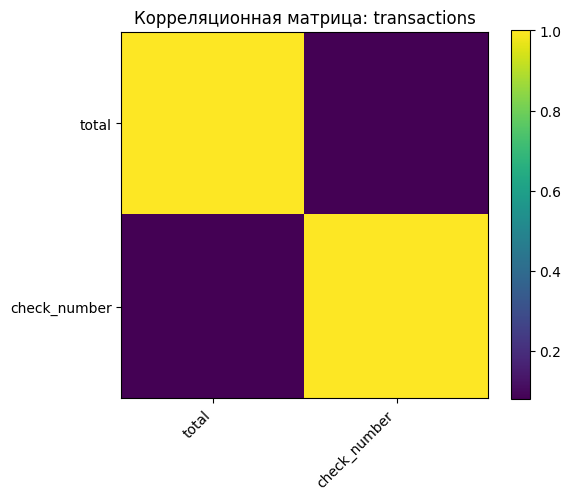

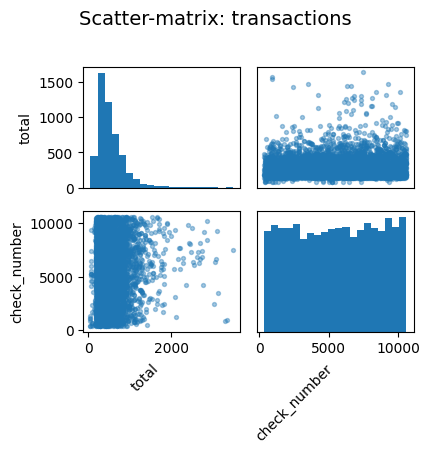

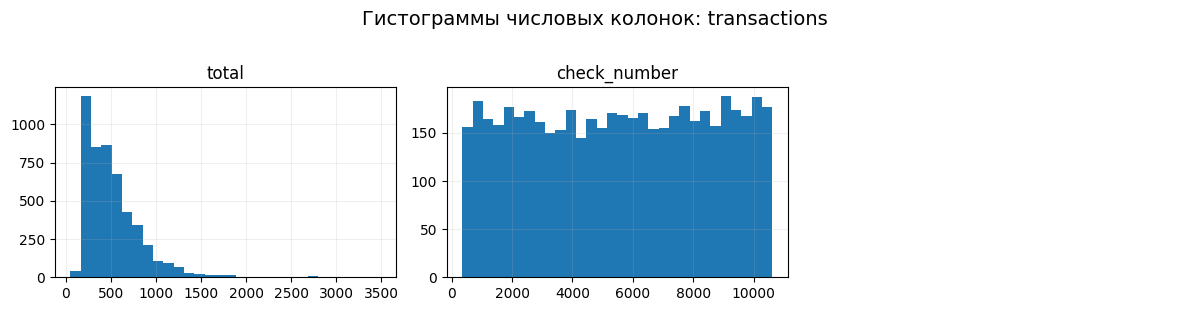

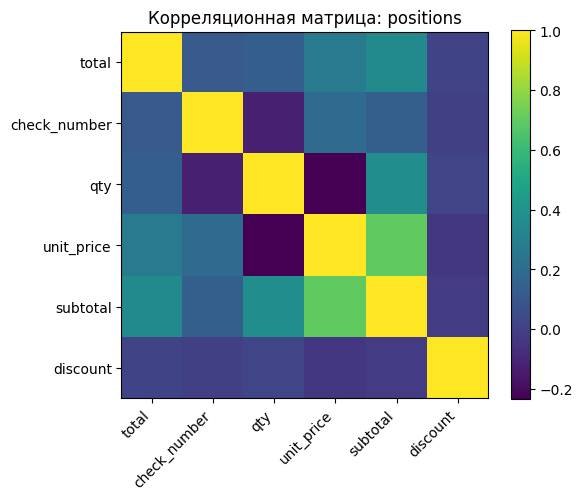

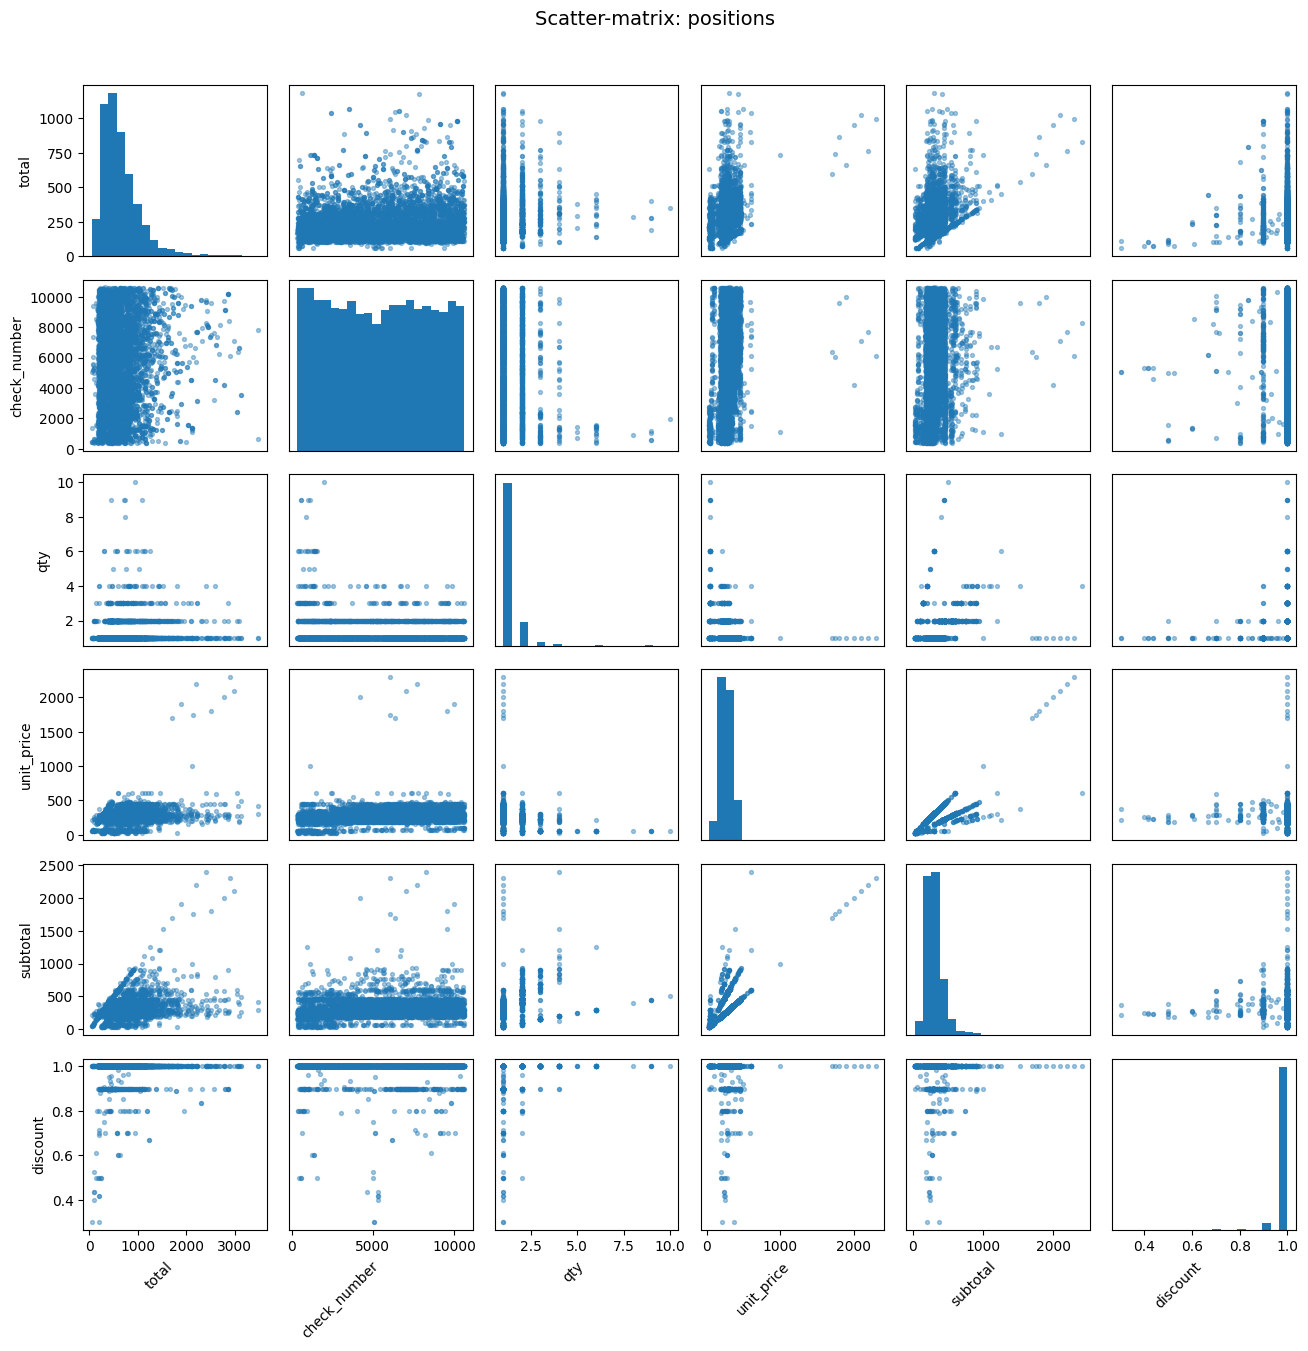

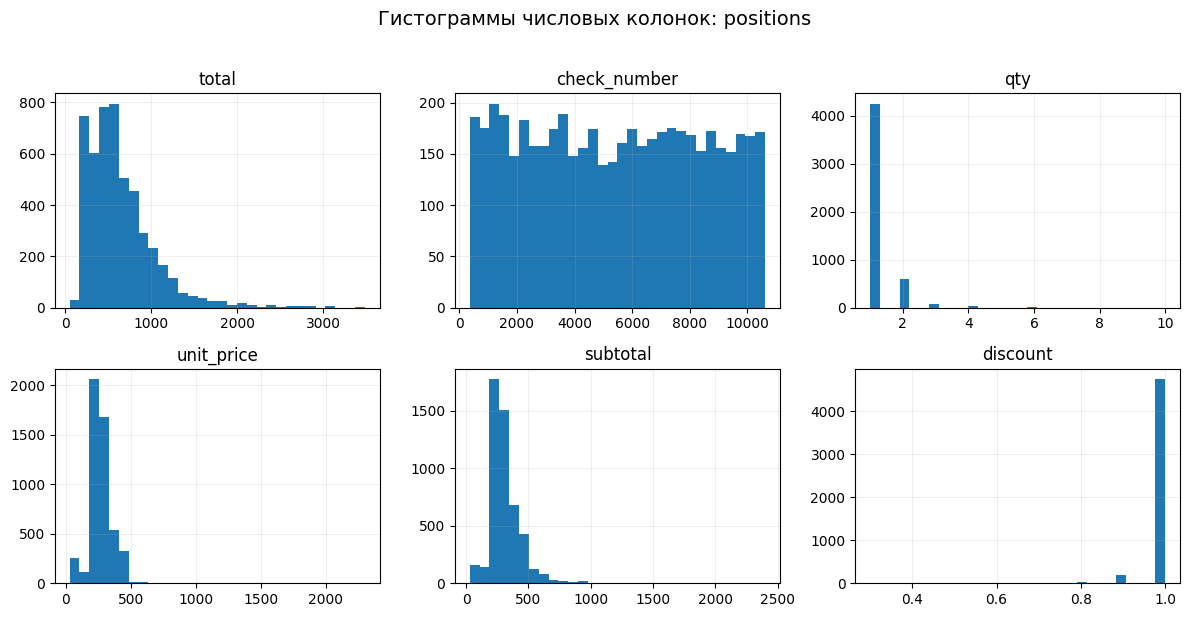

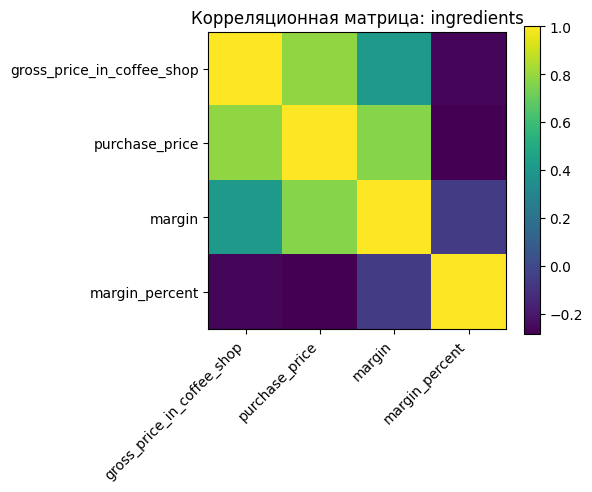

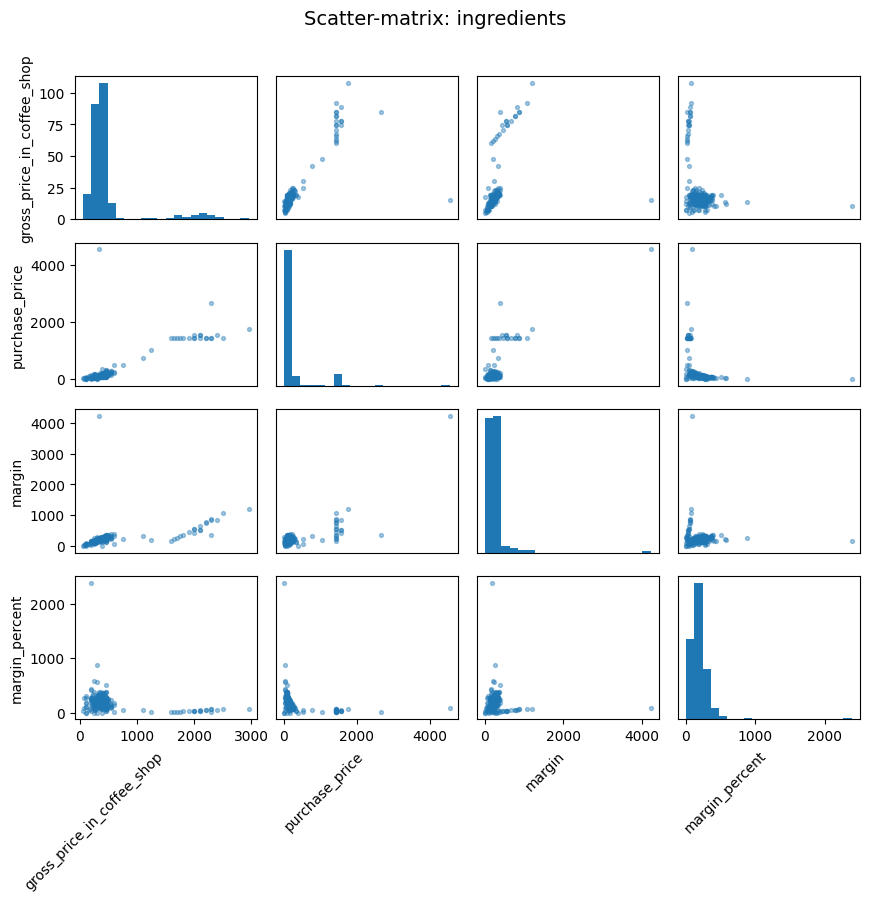

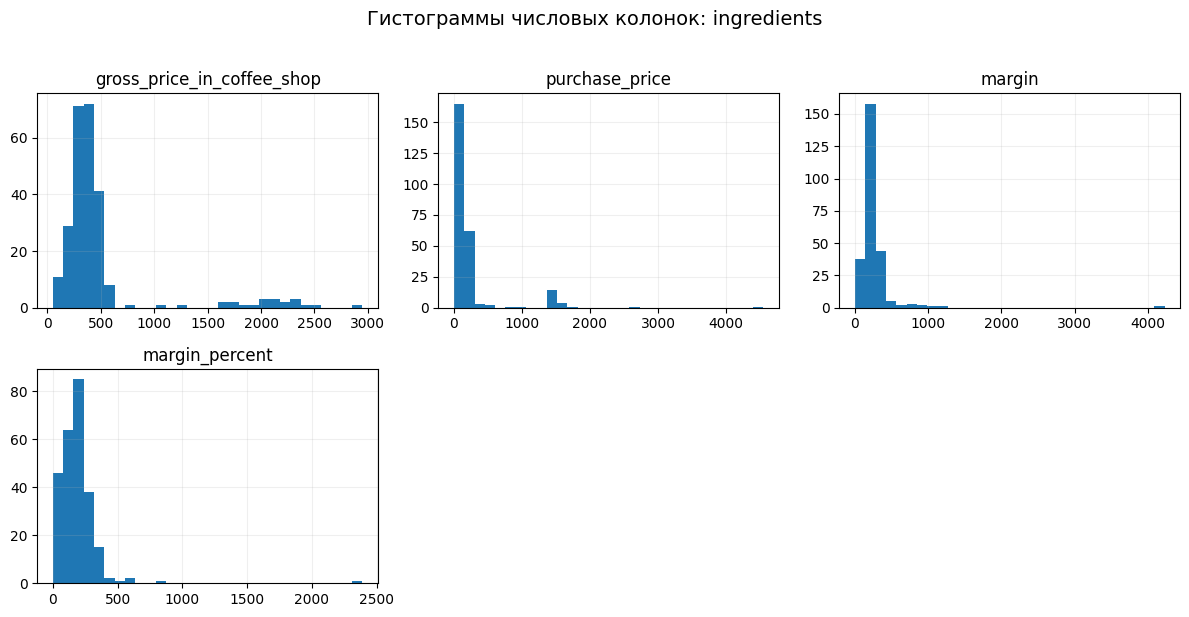

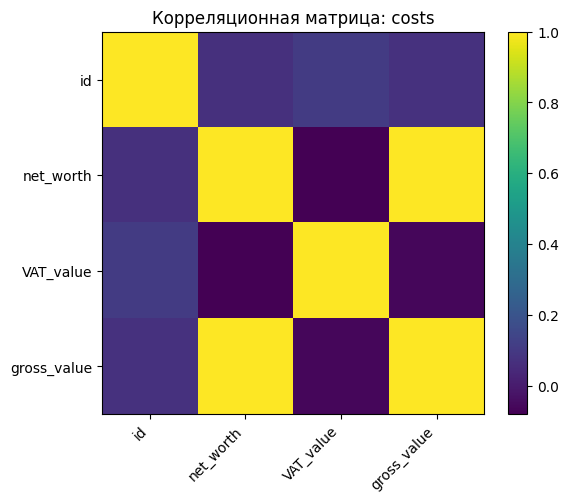

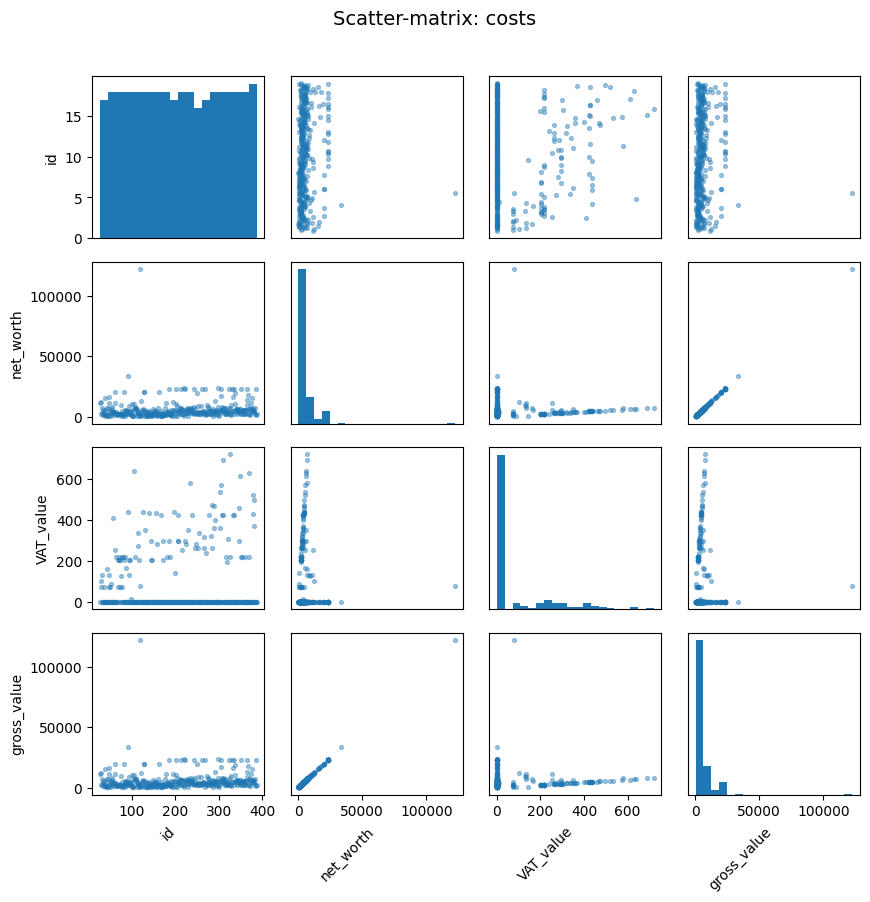

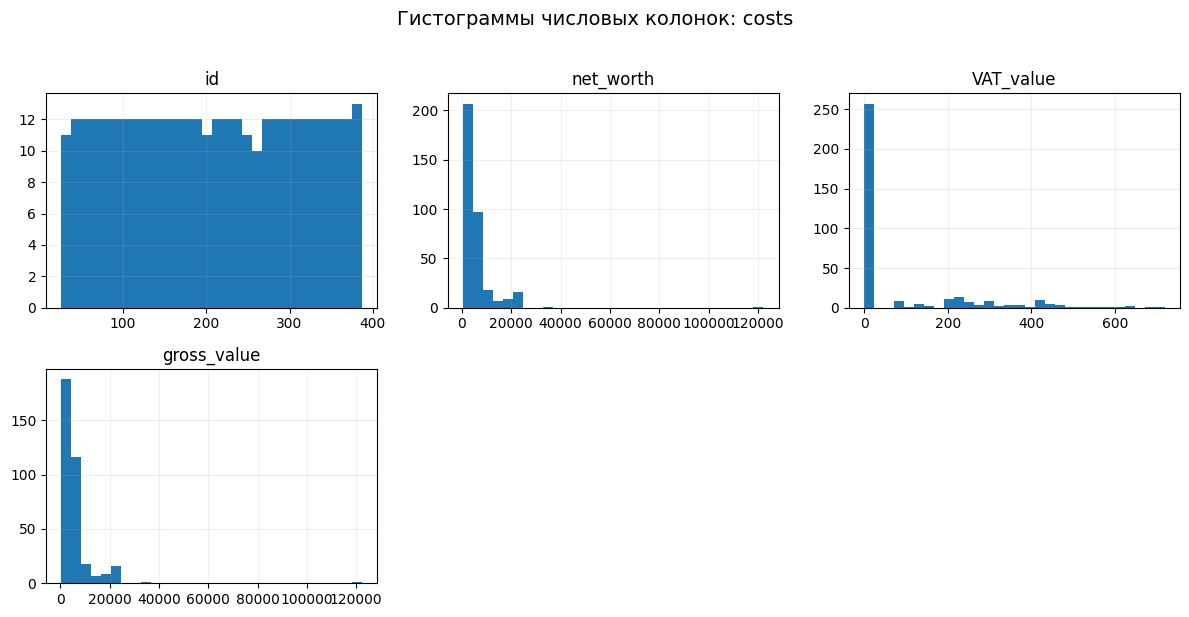

In [58]:
correlation_dashboard(transactions, "transactions", max_cols=8, sample_size=5000)
correlation_dashboard(positions, "positions", max_cols=8, sample_size=5000)
correlation_dashboard(ingredients, "ingredients", max_cols=8, sample_size=None)
correlation_dashboard(costs, "costs", max_cols=8, sample_size=None)

## Количество чеков по месяцам/дням в 2025

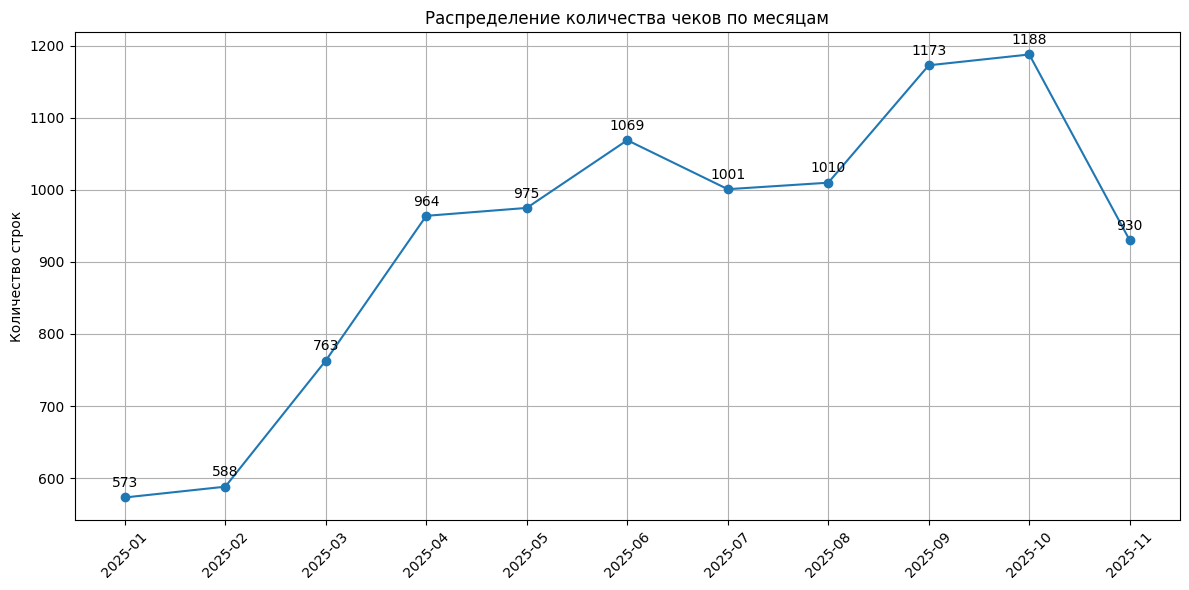

In [59]:
# считаем количество строк по месяцам
counts = (
    transactions['datetime']
        .dt.to_period('M')
        .value_counts()
        .sort_index()
)

# построение графика
plt.figure(figsize=(12, 6))
plt.plot(counts.index.astype(str), counts.values, marker='o')

# подписи значений
for x, y in zip(counts.index.astype(str), counts.values):
    plt.text(x, y + 10, str(y), ha='center', va='bottom')

plt.title("Распределение количества чеков по месяцам")
plt.ylabel("Количество строк")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

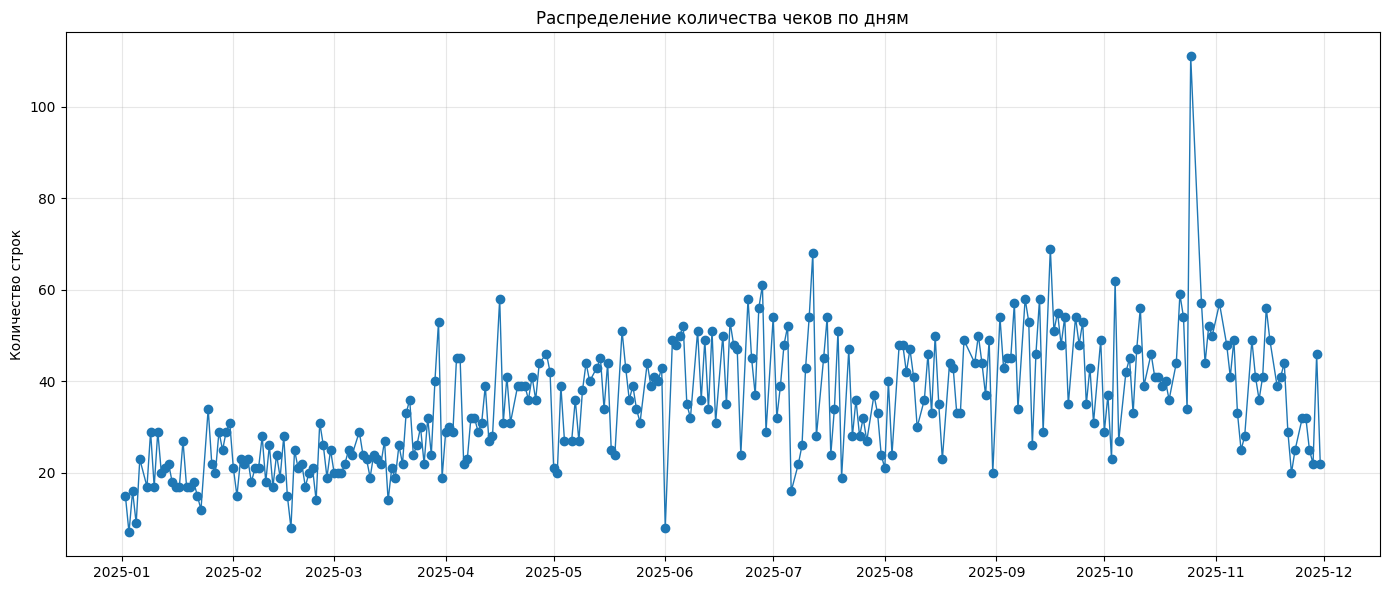

In [60]:
# считаем количество чеков по дням
counts_daily = (
    transactions['datetime']
    .dt.to_period('D')
    .value_counts()
    .sort_index()
)

# переводим PeriodIndex → datetime (обязательно!)
dates = counts_daily.index.to_timestamp()

plt.figure(figsize=(14, 6))
plt.plot(dates, counts_daily.values, marker='o', linewidth=1)

plt.title("Распределение количества чеков по дням")
plt.ylabel("Количество строк")

# сетка
plt.grid(True, alpha=0.3)

# тики по месяцам
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

In [61]:
top5_max = counts_daily.sort_values(ascending=False).head(5)
top5_min = counts_daily.sort_values(ascending=True).head(5)

print("Топ-5 дней с максимальным количеством чеков:")
print(top5_max)

print("\nТоп-5 дней с минимальным количеством чеков:")
print(top5_min)

Топ-5 дней с максимальным количеством чеков:
datetime
2025-10-25    111
2025-09-16     69
2025-07-12     68
2025-10-04     62
2025-06-28     61
Freq: D, Name: count, dtype: int64

Топ-5 дней с минимальным количеством чеков:
datetime
2025-01-03     7
2025-02-17     8
2025-06-01     8
2025-01-05     9
2025-01-23    12
Freq: D, Name: count, dtype: int64


## Количество позиций по месяцам/дням в 2025

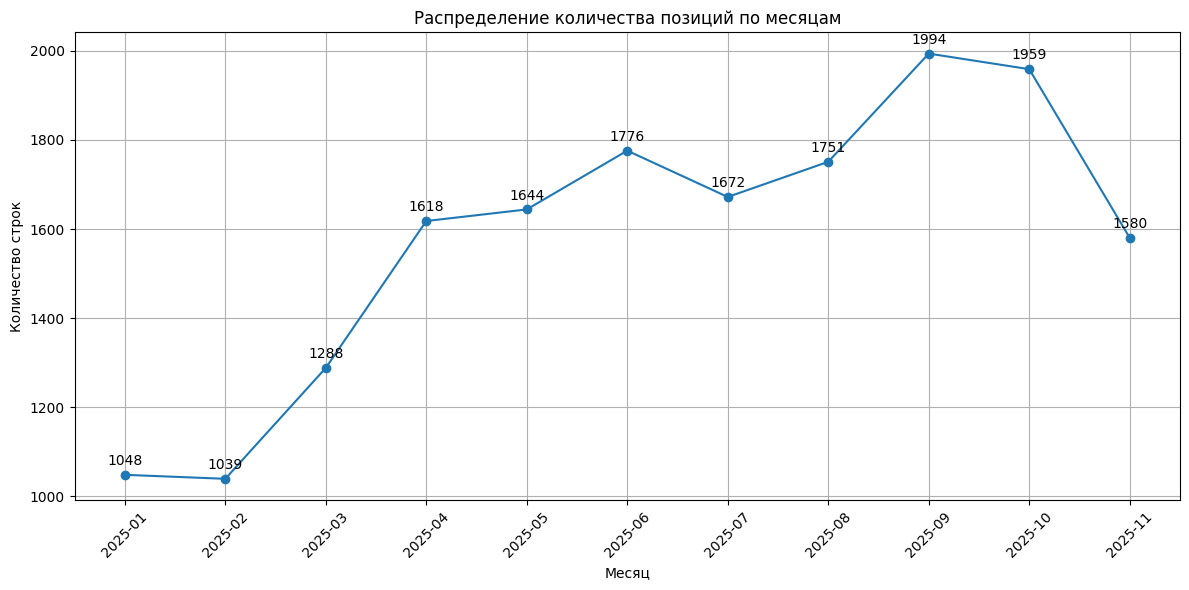

In [62]:
# количество позиций по месяцам
counts_by_month = (
    positions['datetime']
    .dt.to_period('M')
    .value_counts()
    .sort_index()
)

# построение графика
plt.figure(figsize=(12, 6))
plt.plot(counts_by_month.index.astype(str), counts_by_month.values, marker='o')

for x, y in zip(counts_by_month.index.astype(str), counts_by_month.values):
    plt.text(x, y + 15, f"{y}", ha='center', va='bottom')

plt.title("Распределение количества позиций по месяцам")
plt.ylabel("Количество строк")
plt.xlabel("Месяц")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

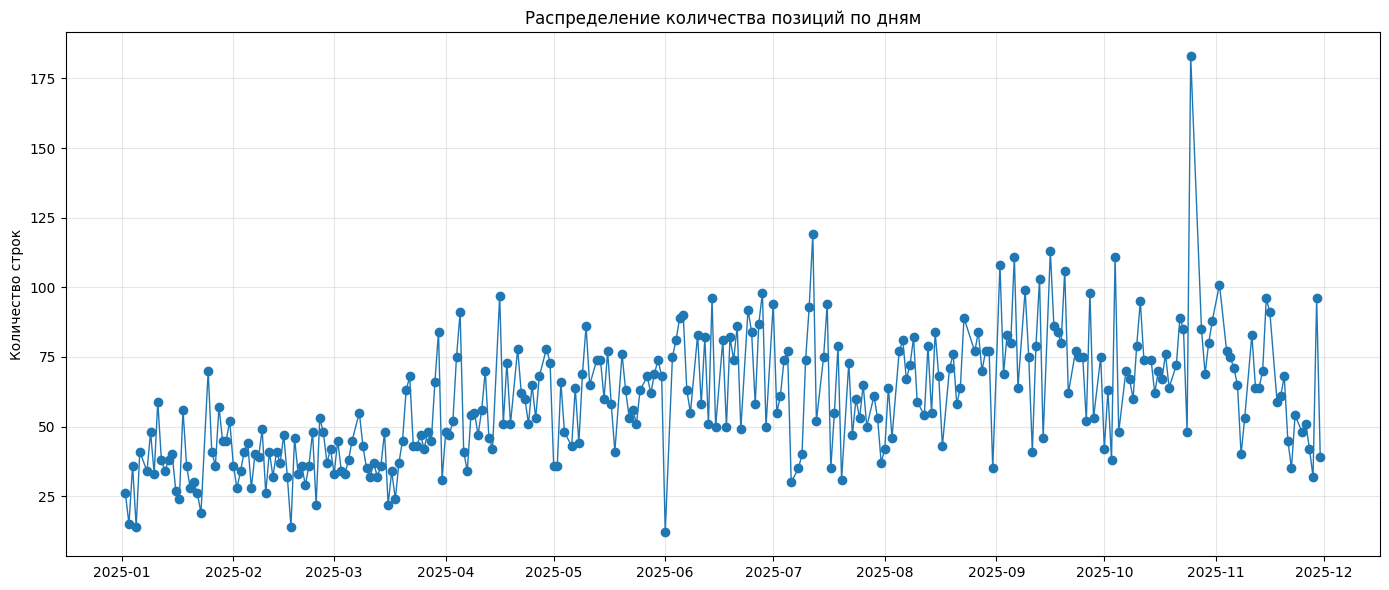

In [63]:
# считаем количество позиций по дням
counts_by_day = (
    positions['datetime']
    .dt.to_period('D')
    .value_counts()
    .sort_index()
)

# переводим PeriodIndex → datetime
dates = counts_by_day.index.to_timestamp()

plt.figure(figsize=(14, 6))
plt.plot(dates, counts_by_day.values, marker='o', linewidth=1)

plt.title("Распределение количества позиций по дням")
plt.ylabel("Количество строк")

# 🔹 сетка
plt.grid(True, alpha=0.3)

# 🔹 тики по месяцам
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

In [64]:
top5_max = counts_by_day.sort_values(ascending=False).head(5)
top5_min = counts_by_day.sort_values(ascending=True).head(5)

print("Топ-5 дней с максимальным количеством позиций:")
print(top5_max)

print("\nТоп-5 дней с минимальным количеством позиций:")
print(top5_min)

Топ-5 дней с максимальным количеством позиций:
datetime
2025-10-25    183
2025-07-12    119
2025-09-16    113
2025-09-06    111
2025-10-04    111
Freq: D, Name: count, dtype: int64

Топ-5 дней с минимальным количеством позиций:
datetime
2025-06-01    12
2025-01-05    14
2025-02-17    14
2025-01-03    15
2025-01-23    19
Freq: D, Name: count, dtype: int64


## Доход по месяцам/дням в 2025

In [65]:
# группируем суммы по месяцам
monthly_income = (
    transactions.groupby(transactions['datetime'].dt.to_period('M'))['total']
      .sum()
      .sort_index()
)

monthly_income

datetime
2025-01    270327.60
2025-02    280453.00
2025-03    352697.03
2025-04    469779.01
2025-05    494022.00
2025-06    558173.60
2025-07    548336.51
2025-08    568207.00
2025-09    654148.50
2025-10    630814.00
2025-11    511573.02
Freq: M, Name: total, dtype: float64

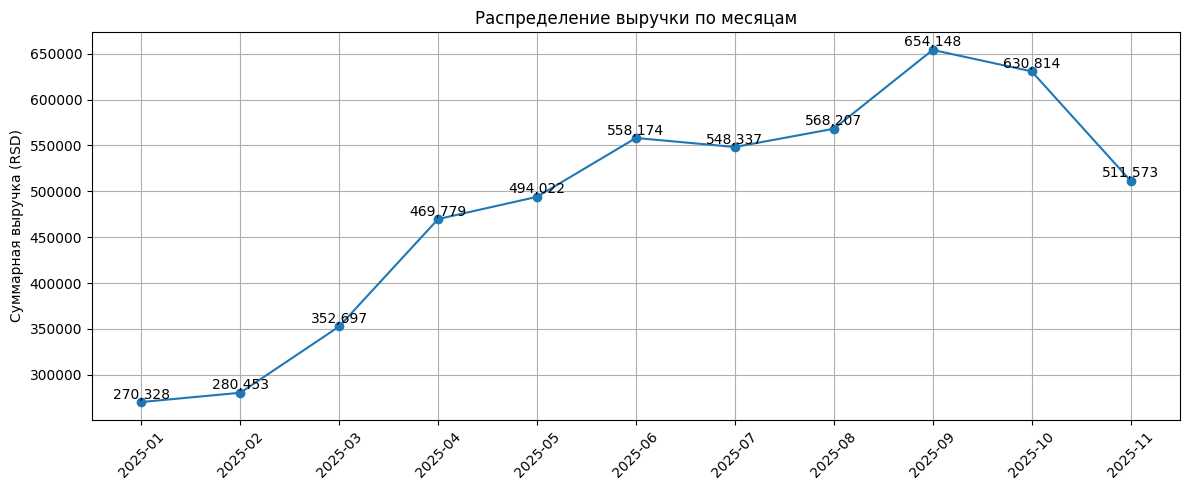

In [66]:
# построение графика
plt.figure(figsize=(12, 5))
plt.plot(monthly_income.index.astype(str), monthly_income.values, marker='o')

# подписи значений на графике
for x, y in zip(monthly_income.index.astype(str), monthly_income.values):
    plt.text(x, y + 500, f"{y:,.0f}", ha='center', va='bottom')

plt.title("Распределение выручки по месяцам")
plt.ylabel("Суммарная выручка (RSD)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

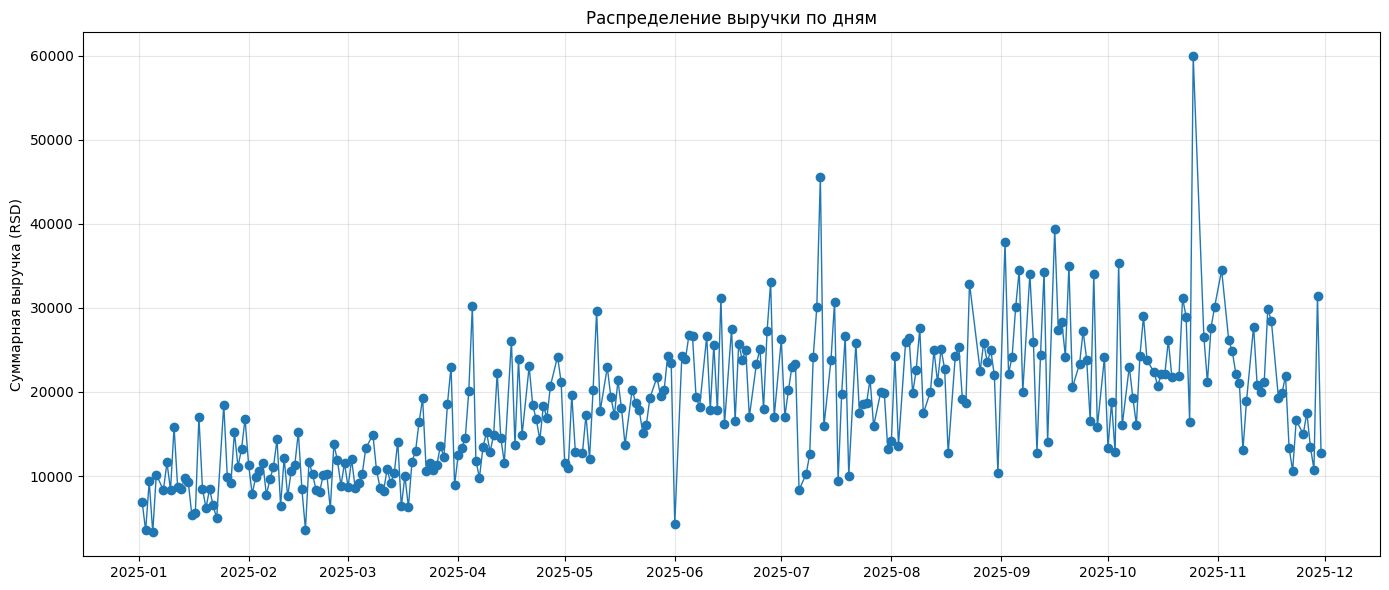

In [67]:
# считаем доход по каждому дню
daily_income = (
    transactions
    .groupby(transactions['datetime'].dt.to_period('D'))['total']
    .sum()
    .sort_index()
)

# перевод PeriodIndex → datetime
dates = daily_income.index.to_timestamp()

plt.figure(figsize=(14, 6))
plt.plot(dates, daily_income.values, marker='o', linewidth=1)

plt.title("Распределение выручки по дням")
plt.ylabel("Суммарная выручка (RSD)")

# 🔹 сетка
plt.grid(True, alpha=0.3)

# 🔹 подписи по месяцам
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

In [68]:
top5_max = daily_income.sort_values(ascending=False).head(5)
top5_min = daily_income.sort_values(ascending=True).head(5)

print("Топ-5 дней с максимальным доходом:")
print(top5_max)

print("\nТоп-5 дней с минимальным доходом:")
print(top5_min)

Топ-5 дней с максимальным доходом:
datetime
2025-10-25    59951.0
2025-07-12    45608.0
2025-09-16    39350.0
2025-09-02    37845.0
2025-10-04    35321.0
Freq: D, Name: total, dtype: float64

Топ-5 дней с минимальным доходом:
datetime
2025-01-05    3290.0
2025-01-03    3524.0
2025-02-17    3640.0
2025-06-01    4250.0
2025-01-23    4975.0
Freq: D, Name: total, dtype: float64


## Средний чек по месяцам/дням в 2025

In [69]:
# группируем по месяцу и считаем средний чек
avg_check = (
    transactions.groupby(transactions['datetime'].dt.to_period('M'))['total']
      .mean()
      .sort_index()
)

avg_check

datetime
2025-01    471.775916
2025-02    476.960884
2025-03    462.250367
2025-04    487.322624
2025-05    506.689231
2025-06    522.145557
2025-07    547.788721
2025-08    562.581188
2025-09    557.671355
2025-10    530.988215
2025-11    550.078516
Freq: M, Name: total, dtype: float64

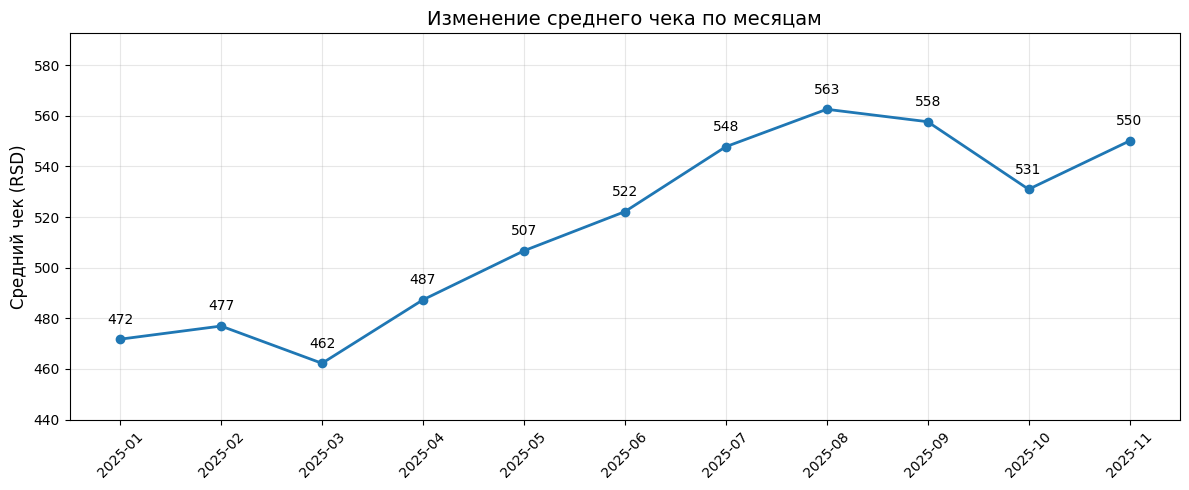

In [70]:
# построение графика
months = avg_check.index.astype(str)
values = avg_check.values
x = range(len(months))

plt.figure(figsize=(12, 5))
plt.plot(x, values, marker='o', linewidth=2)

# подписи над точками
for xi, yi in zip(x, values):
    plt.text(xi, yi + 5, f"{yi:.0f}", ha='center', va='bottom', fontsize=10)

plt.title("Изменение среднего чека по месяцам", fontsize=14)
plt.ylabel("Средний чек (RSD)", fontsize=12)

plt.xticks(x, months, rotation=45)
plt.grid(True, alpha=0.3)

plt.ylim(440, values.max() + 30)

plt.tight_layout()
plt.show()

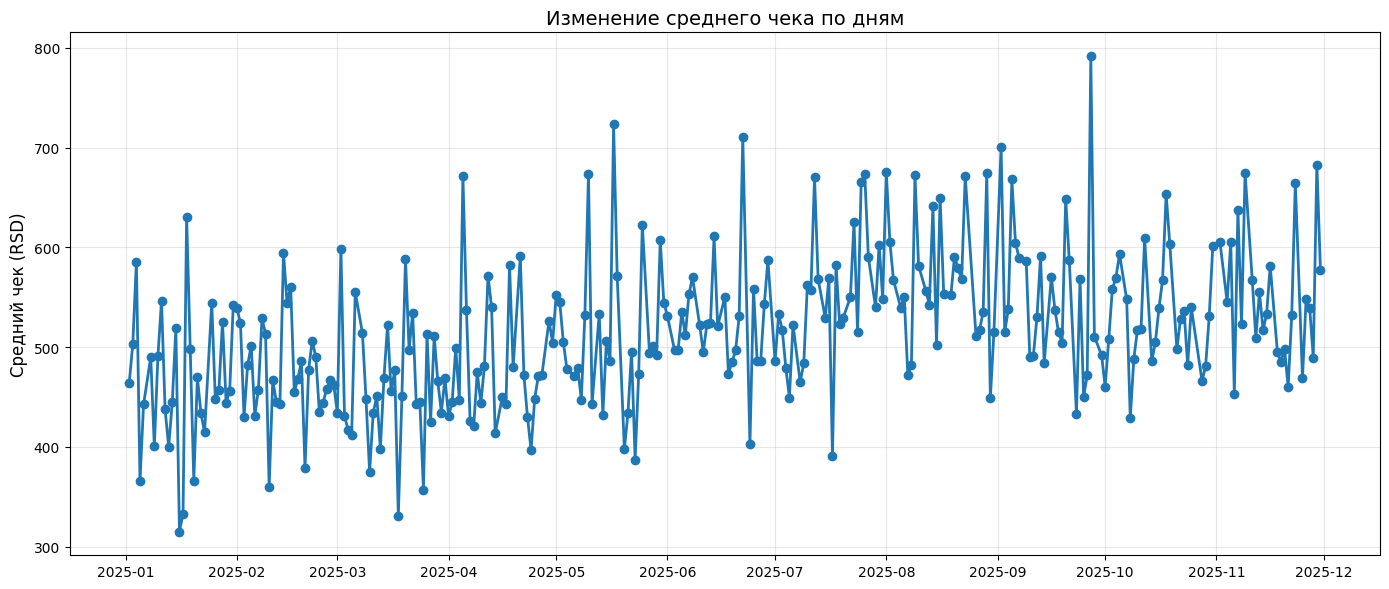

In [71]:
# распределение среднего чека по дням
avg_check_daily = (
    transactions
    .groupby(transactions['datetime'].dt.to_period('D'))['total']
    .mean()
    .sort_index()
)

# перевод PeriodIndex → datetime
dates = avg_check_daily.index.to_timestamp()

# построение графика
plt.figure(figsize=(14, 6))
plt.plot(dates, avg_check_daily.values, marker='o', linewidth=2)

plt.title("Изменение среднего чека по дням", fontsize=14)
plt.ylabel("Средний чек (RSD)", fontsize=12)

# 🔹 сетка
plt.grid(True, alpha=0.3)

# 🔹 подписи по месяцам
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.tight_layout()
plt.show()

In [72]:
top5_max = avg_check_daily.sort_values(ascending=False).head(5)
top5_min = avg_check_daily.sort_values(ascending=True).head(5)

print("Топ-5 дней с максимальным средним чеком:")
print(top5_max)

print("\nТоп-5 дней с минимальным средним чеком:")
print(top5_min)

Топ-5 дней с максимальным средним чеком:
datetime
2025-09-27    791.697674
2025-05-17    723.200000
2025-06-22    710.416667
2025-09-02    700.833333
2025-11-29    683.043478
Freq: D, Name: total, dtype: float64

Топ-5 дней с минимальным средним чеком:
datetime
2025-01-16    315.294118
2025-03-18    331.052632
2025-01-17    332.858824
2025-03-25    357.333333
2025-02-10    359.444444
Freq: D, Name: total, dtype: float64


## Популярные часы посещения

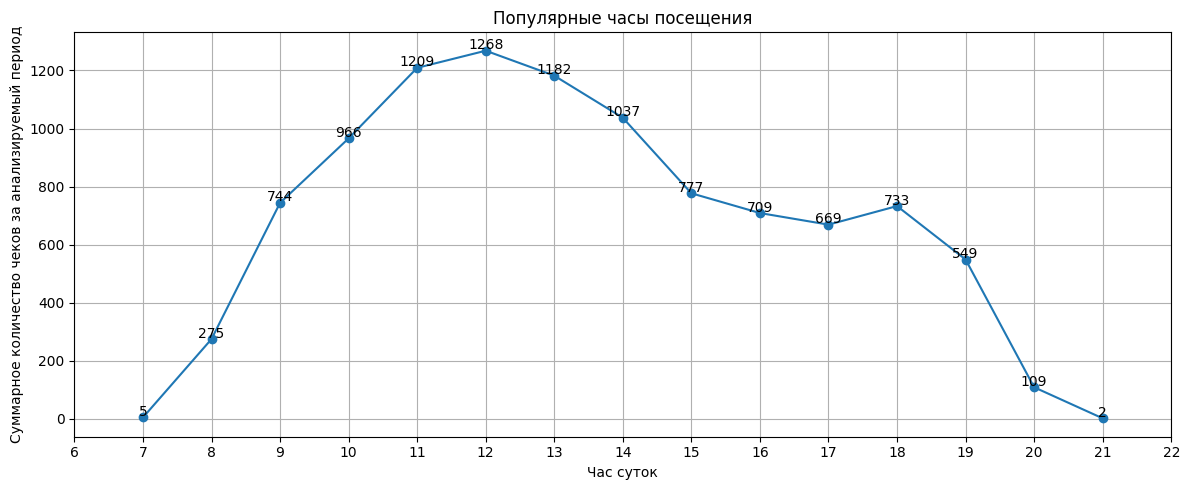

In [73]:
# Часы посещения
transactions['hour'] = transactions['datetime'].dt.hour
counts_hours = transactions['hour'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(counts_hours.index, counts_hours.values, marker='o')

# Подписи над точками
for x, y in zip(counts_hours.index, counts_hours.values):
    if 6 <= x <= 22:
        plt.text(x, y + 5, str(y), ha='center')

plt.title("Популярные часы посещения")
plt.xlabel("Час суток")
plt.ylabel("Суммарное количество чеков за анализируемый период")
plt.xticks(range(6, 24))
plt.xlim(6, 22)
plt.grid(True)
plt.tight_layout()
plt.show()

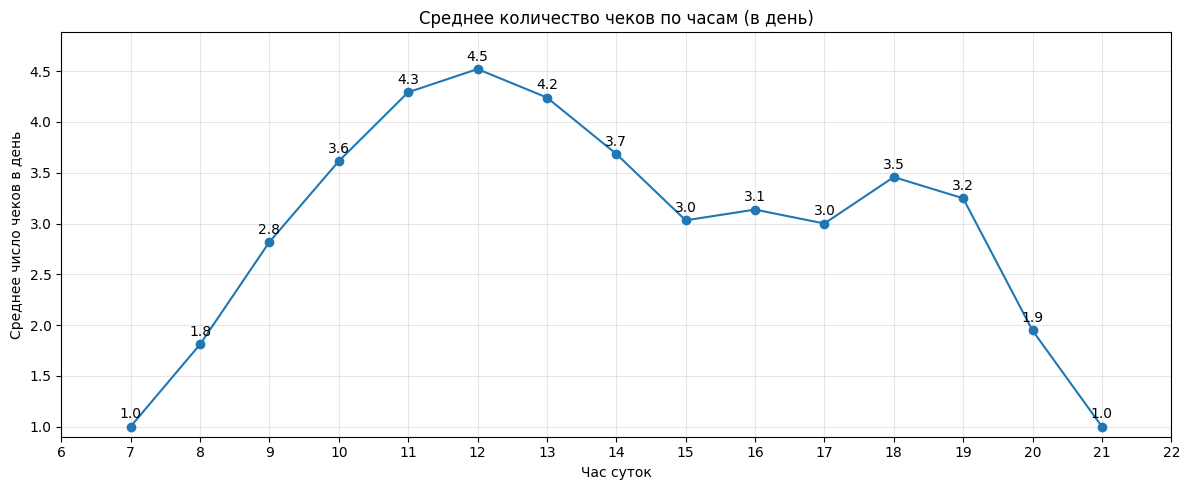

In [74]:
# Ограничиваем период
mask = (
    (transactions['datetime'] >= '2025-01-02') &
    (transactions['datetime'] <= '2025-11-30')
)
tx = transactions.loc[mask].copy()

# Добавляем день и час
tx['date'] = tx['datetime'].dt.date
tx['hour'] = tx['datetime'].dt.hour

# Считаем количество чеков по дням и часам
checks_per_day_hour = (
    tx.groupby(['date', 'hour'])
      .size()
      .reset_index(name='checks')
)

# Считаем среднее по дням для каждого часа
avg_checks_per_hour = (
    checks_per_day_hour
    .groupby('hour')['checks']
    .mean()
)

# оставим только рабочие часы
avg_checks_per_hour = avg_checks_per_hour.loc[6:22]

# Визуализация
plt.figure(figsize=(12, 5))
plt.plot(
    avg_checks_per_hour.index,
    avg_checks_per_hour.values,
    marker='o'
)

# подписи над точками
for x, y in zip(avg_checks_per_hour.index, avg_checks_per_hour.values):
    plt.text(x, y + 0.08, f"{y:.1f}", ha='center', fontsize=10)

plt.title("Среднее количество чеков по часам (в день)")
plt.xlabel("Час суток")
plt.ylabel("Среднее число чеков в день")
plt.xticks(range(6, 23))
plt.xlim(6, 22)

# аккуратные границы оси Y
y_min = avg_checks_per_hour.min()
y_max = avg_checks_per_hour.max()
plt.ylim(y_min * 0.9, y_max * 1.08)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Heatmap посещаемости по дням недели и часам

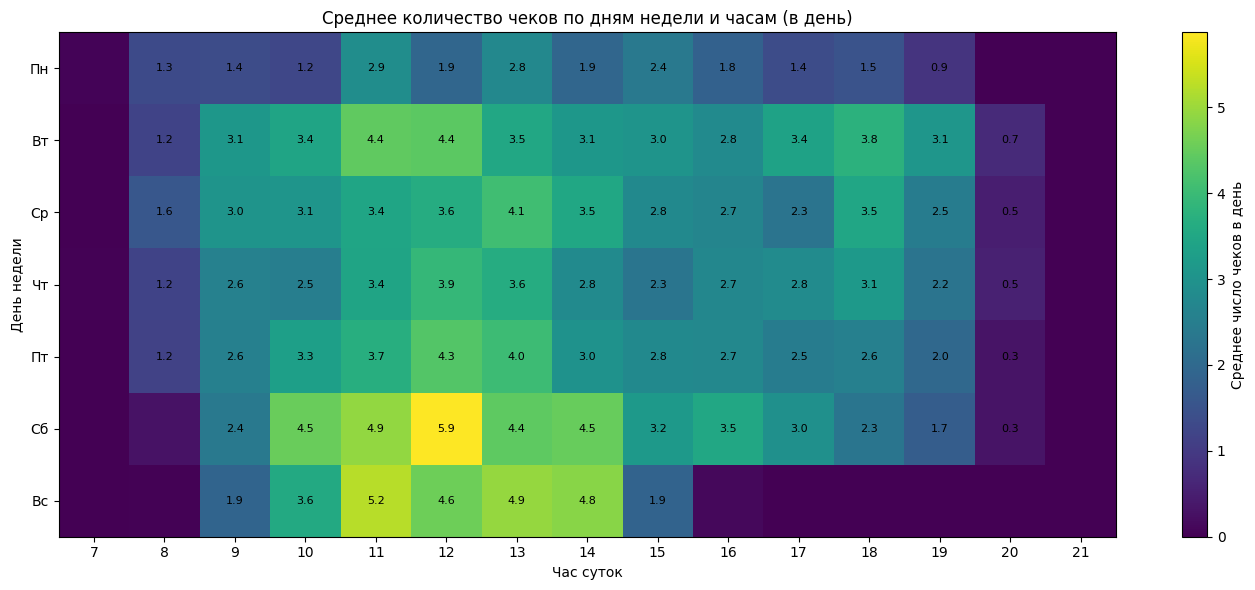

In [75]:
# подготовка
transactions['datetime'] = pd.to_datetime(transactions['datetime'])
transactions['date'] = transactions['datetime'].dt.date
transactions['hour'] = transactions['datetime'].dt.hour
transactions['weekday'] = transactions['datetime'].dt.dayofweek  # 0=Пн..6=Вс
weekday_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

# сколько чеков в (weekday, hour) за весь период
heat_sum = transactions.pivot_table(
    index='weekday',
    columns='hour',
    values='datetime',
    aggfunc='count',
    fill_value=0
)

# сколько уникальных дат было у каждого weekday (для среднего "в день")
days_per_weekday = (
    pd.Series(transactions['date'])
    .groupby(transactions['weekday'])
    .nunique()
)

# среднее число чеков в день для (weekday, hour)
heat_avg = heat_sum.div(days_per_weekday, axis=0)

# чтобы на графике были часы в правильном порядке и только те, что нужны
hours = sorted(heat_avg.columns)
heat_avg = heat_avg[hours]

# визуализация
plt.figure(figsize=(14, 6))
im = plt.imshow(heat_avg.values, aspect='auto')

plt.title("Среднее количество чеков по дням недели и часам (в день)")
plt.xlabel("Час суток")
plt.ylabel("День недели")

plt.xticks(np.arange(len(hours)), hours)
plt.yticks(np.arange(7), weekday_labels)

plt.colorbar(im, label="Среднее число чеков в день")

# подписи внутри ячеек
for i in range(heat_avg.shape[0]):      # weekday
    for j in range(heat_avg.shape[1]):  # hour
        val = heat_avg.iat[i, j]
        # пропускаем совсем маленькие значения, чтобы не шумело
        if val > 0.3:
            plt.text(j, i, f"{val:.1f}", ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

## Самый популярный продукт

In [76]:
# самые популярные позиции за все время анализа
top_products = (
    positions.groupby('group')['qty']
             .sum()
             .sort_values(ascending=False)
)

top_products.head(10)

group
Cappuccino     5989
Dessert        3180
Latte          1332
Espresso       1255
V60             878
Cocoa           783
Americano       578
Flat white      548
Iced Matcha     546
Iced Latte      446
Name: qty, dtype: int64

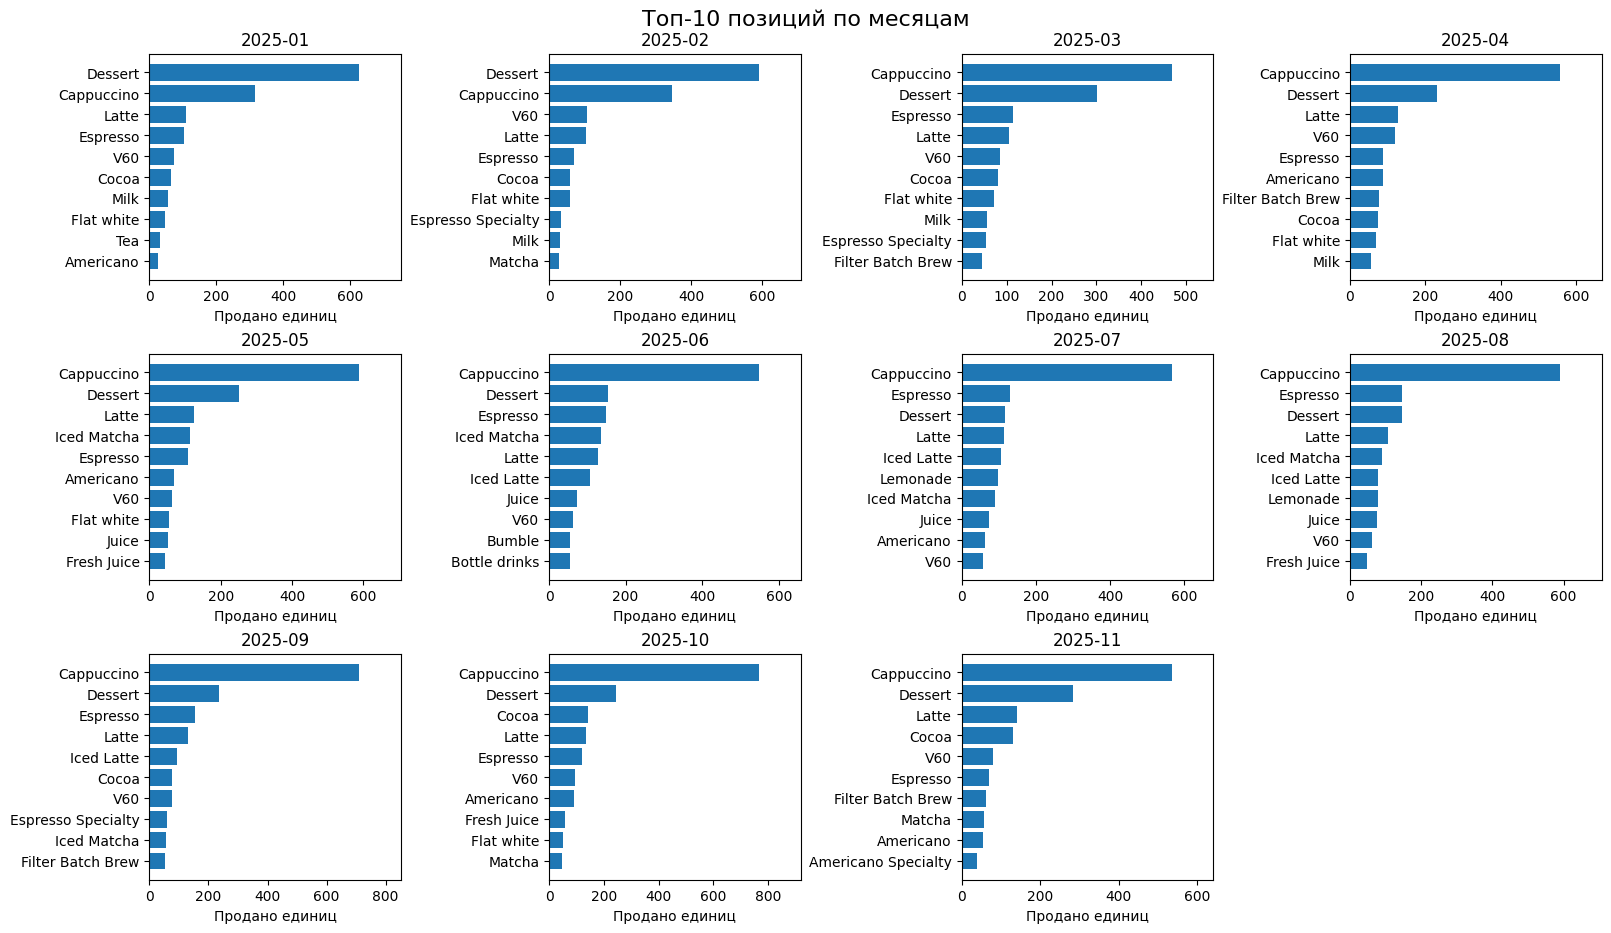

In [77]:
# считаем продажи по месяцам и продуктам
positions['month'] = positions['datetime'].dt.to_period('M')

top5_monthly = (
    positions.groupby(['month', 'group'])['qty']
             .sum()
             .groupby(level=0, group_keys=False)
             .nlargest(10)
)

# список месяцев
months = sorted(top5_monthly.index.get_level_values(0).unique())

# определяем размер сетки — например, 3 строки × 4 столбца
n_months = len(months)
cols = 4
rows = math.ceil(n_months / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 3), constrained_layout=True)

# если сетка 1×N — выравниваем
axes = axes.flatten()

# рисуем каждый месяц в своей ячейке
for ax, month in zip(axes, months):
    group = top5_monthly.loc[month].sort_values()
    
    ax.barh(group.index, group.values)
    ax.set_title(f"{month}")
    ax.set_xlabel("Продано единиц")
    ax.set_xlim(0, group.values.max() * 1.2)  # небольшой запас справа

# на пустых осях убираем всё
for ax in axes[n_months:]:
    ax.axis("off")

plt.suptitle("Топ-10 позиций по месяцам", fontsize=16, y=1.02)
plt.show()

## Топ товаров по выручке (без учета скидок)

In [78]:
revenue_by_product = (
    positions.groupby("group")["subtotal"] # subtotal = qty * unit_price (до скидки)
             .sum()
             .sort_values(ascending=False)
)

revenue_by_product.head(10)

group
Cappuccino     1456070.0
Dessert         512850.0
Latte           385850.0
V60             315660.0
Espresso        253384.0
Cocoa           234190.0
Iced Matcha     225540.0
Flat white      160950.0
Iced Latte      128580.0
Americano       126600.0
Name: subtotal, dtype: float64

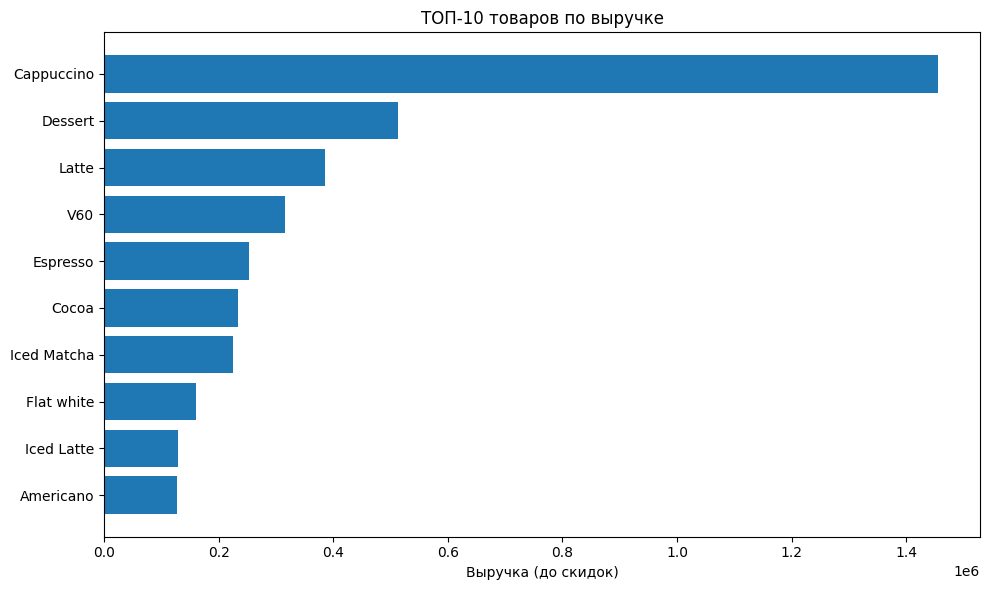

In [79]:
top10_revenue = revenue_by_product.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top10_revenue.index[::-1], top10_revenue.values[::-1])
plt.title("ТОП-10 товаров по выручке")
plt.xlabel("Выручка (до скидок)")
plt.tight_layout()
plt.show()

## Динамика популярности позиций меню

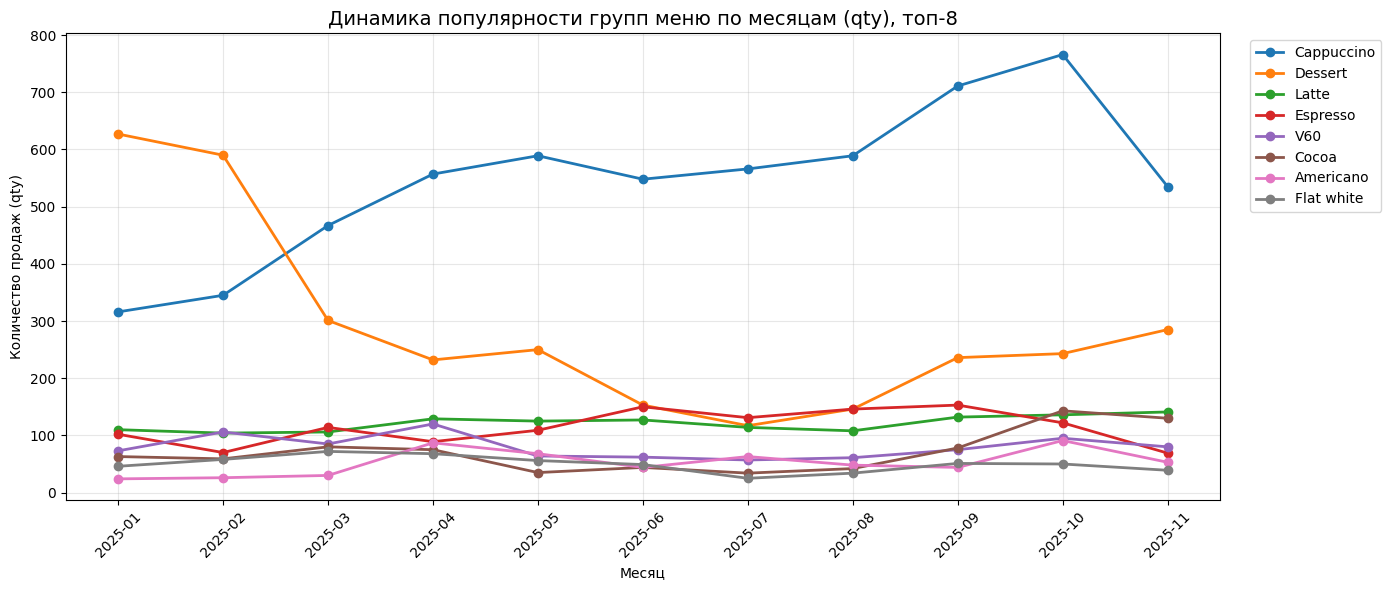

In [80]:
# месяц (Period[M])
positions['month'] = positions['datetime'].dt.to_period('M')

# сводная: строки = месяц, столбцы = группа, значения = qty (сумма)
pivot_qty = (
    positions
    .groupby(['month', 'group'])['qty']
    .sum()
    .unstack('group')
    .fillna(0)
    .sort_index()
)

# возьмем топ-N групп по суммарному qty за весь период
TOP_N = 8
top_groups = pivot_qty.sum(axis=0).sort_values(ascending=False).head(TOP_N).index
pivot_top = pivot_qty[top_groups]

# график
plt.figure(figsize=(14, 6))
x = pivot_top.index.astype(str)

for g in pivot_top.columns:
    plt.plot(x, pivot_top[g].values, marker='o', linewidth=2, label=g)

plt.title(f"Динамика популярности групп меню по месяцам (qty), топ-{TOP_N}", fontsize=14)
plt.xlabel("Месяц")
plt.ylabel("Количество продаж (qty)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

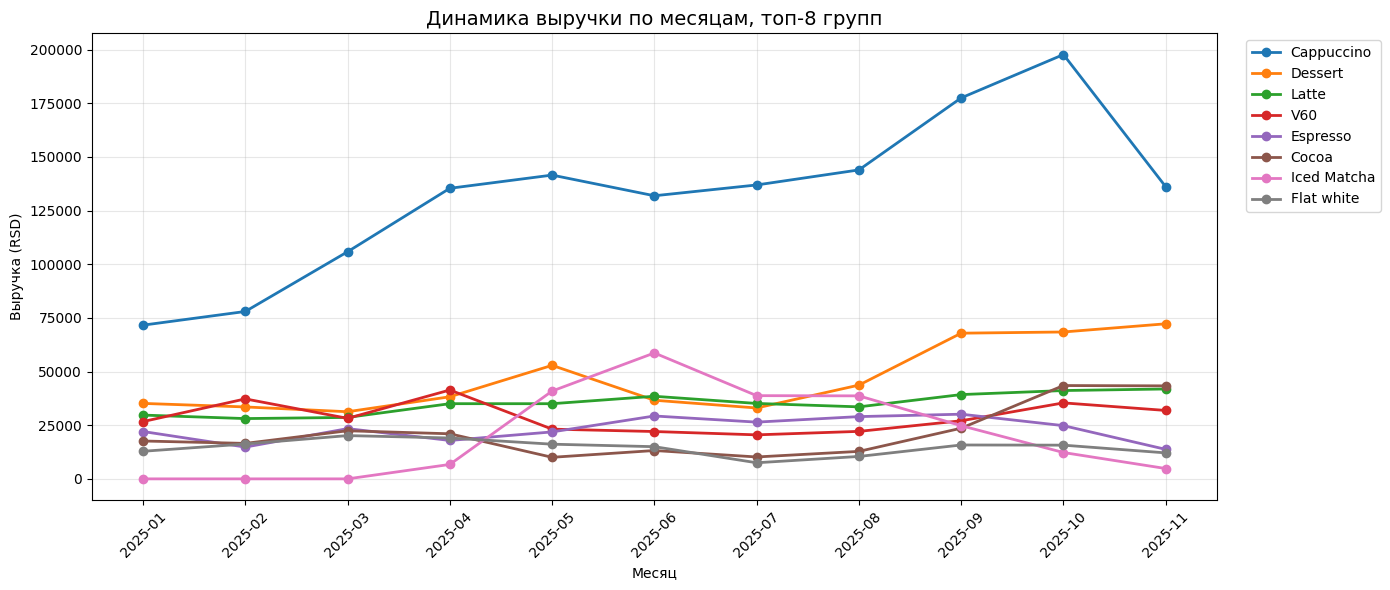

In [81]:
# месяц
positions['month'] = positions['datetime'].dt.to_period('M')

# сводная таблица: выручка по месяцам и группам
pivot_revenue = (
    positions
    .groupby(['month', 'group'])['subtotal']
    .sum()
    .unstack('group')
    .fillna(0)
    .sort_index()
)

# топ-N групп по суммарной выручке за весь период
TOP_N = 8
top_groups = (
    pivot_revenue
    .sum(axis=0)
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)

pivot_top = pivot_revenue[top_groups]

# график
plt.figure(figsize=(14, 6))
x = pivot_top.index.astype(str)

for g in pivot_top.columns:
    plt.plot(x, pivot_top[g], marker='o', linewidth=2, label=g)

plt.title(f"Динамика выручки по месяцам, топ-{TOP_N} групп", fontsize=14)
plt.xlabel("Месяц")
plt.ylabel("Выручка (RSD)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

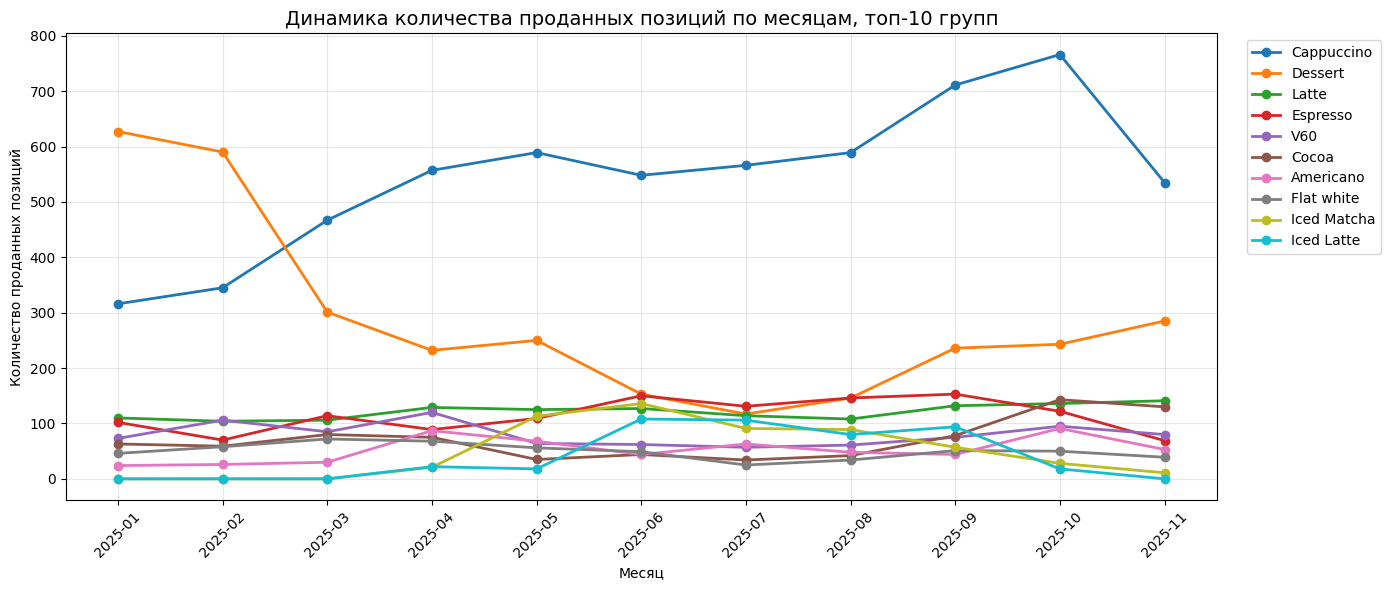

In [82]:
# месяц
positions['month'] = positions['datetime'].dt.to_period('M')

# сводная таблица: выручка по месяцам и группам
pivot_revenue = (
    positions
    .groupby(['month', 'group'])['qty']
    .sum()
    .unstack('group')
    .fillna(0)
    .sort_index()
)

# топ-N групп по суммарной выручке за весь период
TOP_N = 10
top_groups = (
    pivot_revenue
    .sum(axis=0)
    .sort_values(ascending=False)
    .head(TOP_N)
    .index
)

pivot_top = pivot_revenue[top_groups]

# график
plt.figure(figsize=(14, 6))
x = pivot_top.index.astype(str)

for g in pivot_top.columns:
    plt.plot(x, pivot_top[g], marker='o', linewidth=2, label=g)

plt.title(f"Динамика количества проданных позиций по месяцам, топ-{TOP_N} групп", fontsize=14)
plt.xlabel("Месяц")
plt.ylabel("Количество проданных позиций")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Матрица BCG

Позиции 'Kuvano Vino' и 'rod kilaci' не анализируются

**Интерпретация**

| Категория                     | Что означает                              | Что делать                               |
| ----------------------------- | ----------------------------------------- | ---------------------------------------- |
| **Stars (звезды)**            | Высокая маржинальность + высокая доля продаж     | Инвестировать и активно продвигать        |
| **Cash Cows (дойные коровы)** | Низкая маржинальность + высокая доля продаж      | Максимизировать прибыль, снижать расходы  |
| **Question Marks (вопросы)**  | Высокая маржинальность + низкая доля продаж      | Тестировать (обновление меню), стимулировать продажи (дегустации)|
| **Dogs (собаки)**             | Низкая маржинальность + низкая доля продаж       | Удалять или менять позицию                        |

In [83]:
# агрегируем продажи по позициям
sales_stats = (
    positions.groupby('name')
    .agg(
        sales_count=('qty', 'sum'),
        revenue=('subtotal', 'sum')
    )
    .reset_index()
)

In [84]:
total_sales = sales_stats['sales_count'].sum()

sales_stats['sales_share'] = (
    sales_stats['sales_count'] / total_sales
)

In [85]:
# выбираем только нужные колонки из ingredients
margin_data = ingredients[['sale_item', 'margin_percent']]

# объединяем по названию позиции
sales_stats = sales_stats.merge(
    margin_data,
    left_on='name',
    right_on='sale_item',
    how='left'
)

# удаляем временный столбец
sales_stats.drop(columns=['sale_item'], inplace=True)

In [86]:
median_share = sales_stats['sales_share'].median()
median_margin = sales_stats['margin_percent'].median(skipna=True)

print('median_share =', median_share)
print('median_margin =', median_margin)

UNKNOWN_LABEL = "Не удалось проанализировать"

def bcg_category(row):
    # если нет маржи – отдельная группа
    if pd.isna(row['margin_percent']):
        return UNKNOWN_LABEL

    if row['sales_share'] >= median_share and row['margin_percent'] >= median_margin:
        return "Star"
    elif row['sales_share'] >= median_share and row['margin_percent'] < median_margin:
        return "Cash Cow"
    elif row['sales_share'] < median_share and row['margin_percent'] >= median_margin:
        return "Question Mark"
    else:
        return "Dog"

sales_stats['BCG_type'] = sales_stats.apply(bcg_category, axis=1)
sales_stats['BCG_type'].value_counts()

median_share = 0.00042629784009094355
median_margin = 173.02


BCG_type
Не удалось проанализировать    96
Cash Cow                       66
Star                           57
Question Mark                  51
Dog                            41
Name: count, dtype: int64

In [87]:
def show_bcg_group(data, group_name, title):

    '''
    revenue — абсолютная выручка по позиции за весь анализируемый период (сумма total по всем чекам для этой позиции)
    sales_count — общее количество проданных единиц позиции за анализируемый период (сумма qty по всем чекам)
        высокий sales_count → массовый продукт
        низкий sales_count → нишевый / редкий продукт
    sales_share — доля продаж позиции относительно всех продаж
    margin_percent — процент маржи по позиции
    '''
    
    df = data[data["BCG_type"] == group_name].copy()
    if df.empty:
        print(f"Группа '{group_name}' пуста")
        return

    df = df.sort_values(by="revenue", ascending=False)

    tbl = df[["name", "revenue", "sales_count", "sales_share", "margin_percent"]] \
            .set_index("name")

    styler = tbl.style.set_caption(title)

    # Градиент только там, где есть хоть одно не-NaN
    if df["sales_count"].notna().any():
        styler = styler.background_gradient(subset=["sales_count"], cmap="YlGn")

    if df["sales_share"].notna().any():
        styler = styler.background_gradient(subset=["sales_share"], cmap="YlGn")

    if df["margin_percent"].notna().any():
        styler = styler.background_gradient(subset=["margin_percent"], cmap="YlGn")

    styler = styler.format({
        "revenue":        lambda x: f"{int(x):,} RSD".replace(",", "."),
        "sales_share":    lambda x: f"{x*100:.2f} %",
        "margin_percent": lambda x: "-" if pd.isna(x) else f"{x:.1f} %"
    })

    display(styler)

Для кофейни нормальная маржинальность по продукту:

**Напитки**
- 70–150 % — нормально
- 150–300 % — отлично
- больше 300 % — очень хорошо, но стоит проверить расчёт

**Десерты**
- 50–100 % — нормально
- 100–150 % — хорошо

**Зерна**
- 30–70 % — нормально
- больше 70 % — хорошо

In [88]:
show_bcg_group(
    sales_stats,
    "Star",
    "Stars — топ позиции меню (высокая выручка + высокая доля продаж)"
)

,revenue,sales_count,sales_share,margin_percent
name,,,,
Latte,334.420 RSD,1190,5.64 %,174.2 %
Espresso,193.800 RSD,1020,4.83 %,268.2 %
Iced Latte,128.580 RSD,446,2.11 %,174.2 %
Doppio specijalitet,95.450 RSD,312,1.48 %,207.5 %
Americano,92.690 RSD,451,2.14 %,307.0 %
Bumble Coffee,91.140 RSD,223,1.06 %,173.0 %
Narandza,87.940 RSD,336,1.59 %,302.8 %
Cappuccino soya,75.280 RSD,258,1.22 %,238.6 %
Zova,59.600 RSD,298,1.41 %,409.4 %


In [89]:
show_bcg_group(
    sales_stats,
    "Cash Cow",
    "Cash Cows — популярные, но менее маржинальные позиции"
)

,revenue,sales_count,sales_share,margin_percent
name,,,,
Cappuccino,837.200 RSD,3640,17.24 %,162.2 %
Mali Cappuccino,281.610 RSD,1341,6.35 %,139.4 %
Iced Matcha Jagoda/Malina,157.910 RSD,390,1.85 %,62.9 %
Kakao ViK,151.800 RSD,511,2.42 %,162.8 %
Flat white,149.750 RSD,518,2.45 %,115.3 %
Cappuccino XL,142.080 RSD,384,1.82 %,135.1 %
Macha Latte,84.920 RSD,268,1.27 %,112.1 %
Brownies,73.750 RSD,317,1.50 %,129.2 %
Spanish Iced Latte,63.730 RSD,170,0.81 %,95.8 %


In [90]:
show_bcg_group(
    sales_stats,
    "Question Mark",
    "Question Marks — маржинальные, но не популярные"
)

,revenue,sales_count,sales_share,margin_percent
name,,,,
Mocha coffee,3.600 RSD,8,0.04 %,178.6 %
Dzin Koktel,3.300 RSD,6,0.03 %,235.9 %
portional V60 tasty,2.960 RSD,8,0.04 %,309.6 %
iced V60 Hotel Beograd,2.700 RSD,6,0.03 %,190.6 %
Espresso Freddo Spec,2.660 RSD,8,0.04 %,237.3 %
mali cappuccino aka cortado,2.280 RSD,8,0.04 %,269.9 %
tst decaf V60,2.100 RSD,7,0.03 %,305.4 %
Cappuccino Freddo Spec,2.040 RSD,6,0.03 %,173.7 %
Cappuccino Ovseno Specialty,1.900 RSD,5,0.02 %,198.7 %


In [91]:
show_bcg_group(
    sales_stats,
    "Dog",
    "Dogs — слабые позиции в меню"
)

,revenue,sales_count,sales_share,margin_percent
name,,,,
1900,15.200 RSD,8,0.04 %,32.6 %
1750,12.250 RSD,7,0.03 %,22.2 %
2500,7.500 RSD,3,0.01 %,74.5 %
2200,6.600 RSD,3,0.01 %,53.6 %
2000,6.000 RSD,3,0.01 %,39.6 %
2300,4.600 RSD,2,0.01 %,60.6 %
2100,4.200 RSD,2,0.01 %,46.6 %
Kenya Papa Bean,4.200 RSD,2,0.01 %,34.0 %
Panonski Brodolomac,4.000 RSD,8,0.04 %,97.2 %


In [92]:
show_bcg_group(
    sales_stats,
    "Не удалось проанализировать",
    "Не удалось проанализировать — нет данных по маржинальности из-за несовпадения названий в таблице транзакций и таблице составов"
)

,revenue,sales_count,sales_share,margin_percent
name,,,,
Oreški,69.750 RSD,1395,6.61 %,-
Cold Brew Melo,27.490 RSD,71,0.34 %,-
Kroasan,25.800 RSD,172,0.81 %,-
Colombia Huila Los Patios HB1937 V60,21.150 RSD,47,0.22 %,-
Filter Melo Ethiopia Chelbesa,20.630 RSD,73,0.35 %,-
Topla cokolada,19.880 RSD,71,0.34 %,-
Kakao Classic,17.920 RSD,64,0.30 %,-
Freya American Blond,12.090 RSD,31,0.15 %,-
v60 papabean,11.700 RSD,39,0.18 %,-


## Популярность по сегментам

### Динамика популярности обжарщиков (линейная диаграмма)

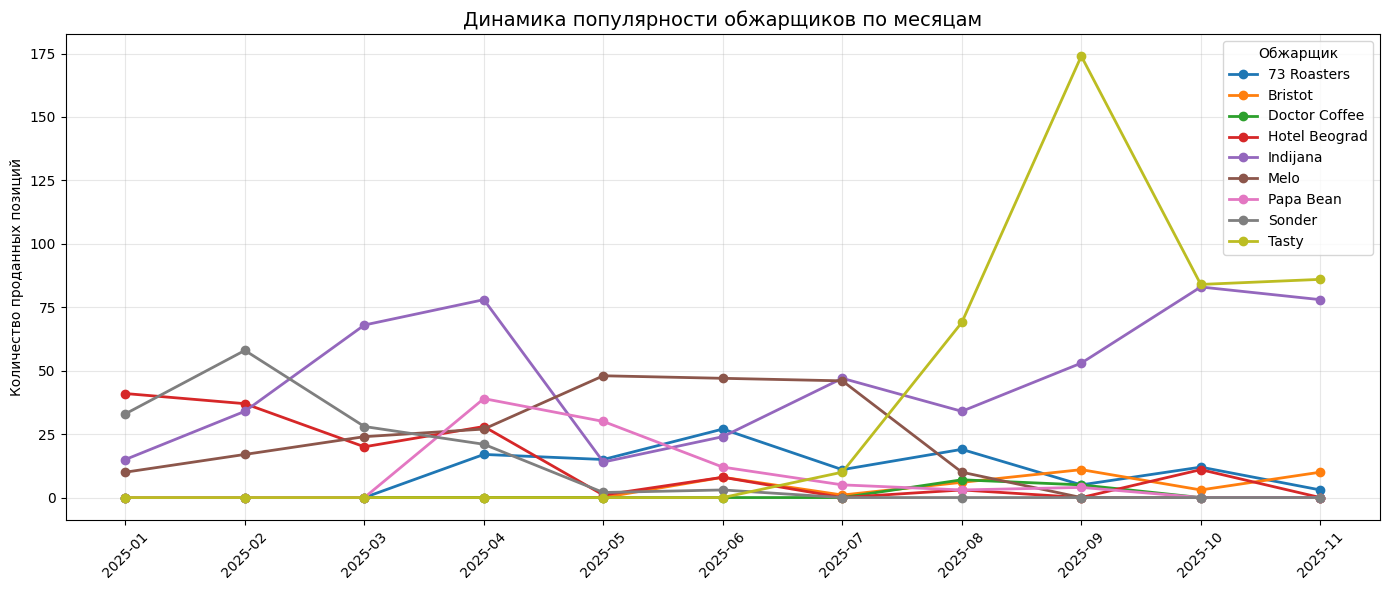

In [93]:
# копия на всякий случай
df_roaster = positions.copy()

# убираем строки без обжарщика
df_roaster = df_roaster.dropna(subset=['roaster'])

# месяц в формате YYYY-MM
df_roaster['month'] = df_roaster['datetime'].dt.to_period('M').astype(str)

# агрегируем: количество проданных позиций
roaster_monthly = (
    df_roaster
    .groupby(['month', 'roaster'])['qty']
    .sum()
    .reset_index()
)

roaster_pivot = roaster_monthly.pivot(
    index='month',
    columns='roaster',
    values='qty'
).fillna(0)

plt.figure(figsize=(14, 6))

for roaster in roaster_pivot.columns:
    plt.plot(
        roaster_pivot.index,
        roaster_pivot[roaster],
        marker='o',
        linewidth=2,
        label=roaster
    )

plt.title("Динамика популярности обжарщиков по месяцам", fontsize=14)
plt.ylabel("Количество проданных позиций")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title="Обжарщик")
plt.tight_layout()
plt.show()

# Indijana и 73 выглядят неправдоподобно
# Учитывать, что Bristot здесь - только покупка зерна (т.к. в таблице не указан обжарщик на покупку не спешалти напитков на эспрессо)
# Учитывать, что обжарщик на покупке спешалти напитков на эспрессо тоже не указан

### Популярность декафа (линейная диаграмма)

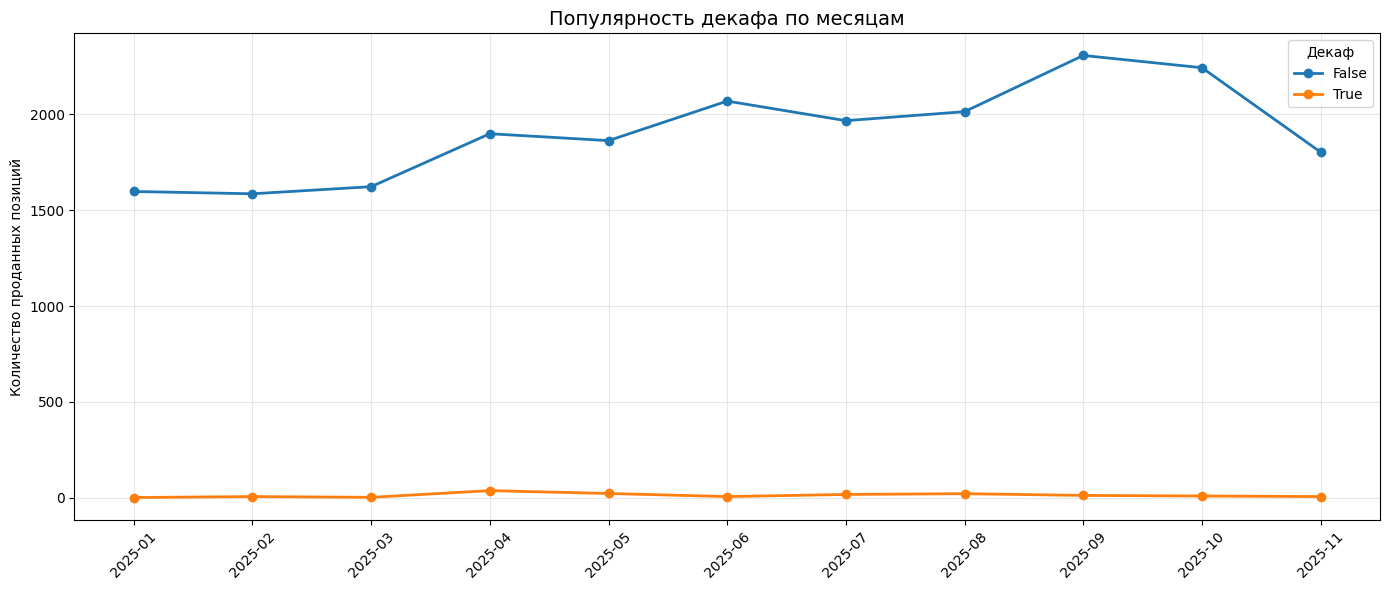

In [94]:
# копия на всякий случай
df = positions.copy()

# месяц в формате YYYY-MM
df['month'] = df['datetime'].dt.to_period('M').astype(str)

# агрегируем: количество проданных позиций
decaf_monthly = (
    df
    .groupby(['month', 'is_decaf'])['qty']
    .sum()
    .reset_index()
)

decaf_pivot = decaf_monthly.pivot(
    index='month',
    columns='is_decaf',
    values='qty'
).fillna(0)

plt.figure(figsize=(14, 6))

for is_decaf in decaf_pivot.columns:
    plt.plot(
        decaf_pivot.index,
        decaf_pivot[is_decaf],
        marker='o',
        linewidth=2,
        label=is_decaf
    )

plt.title("Популярность декафа по месяцам", fontsize=14)
plt.ylabel("Количество проданных позиций")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title="Декаф")
plt.tight_layout()
plt.show()

### Распределение чеков по способу оплаты (линейная диаграмма)

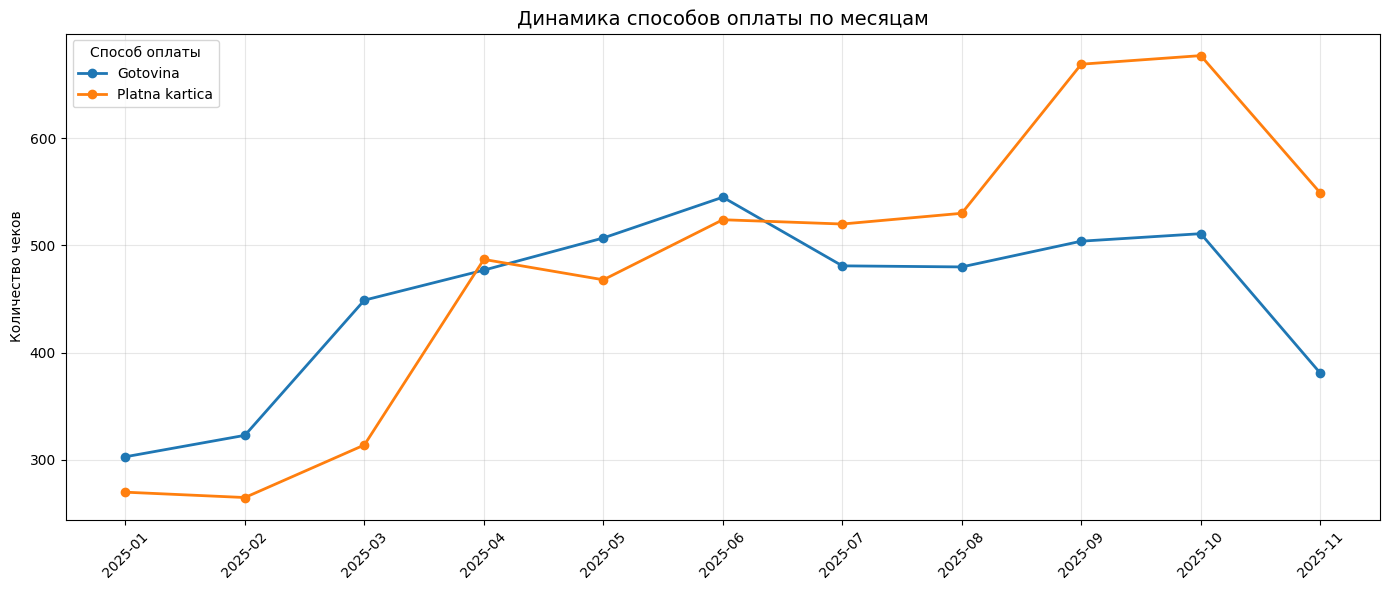

In [95]:
df = positions.copy()

# месяц
df['month'] = df['datetime'].dt.to_period('M').astype(str)

# оставляем только нужное
df_pm = df[['month', 'payment_method', 'check_number']].dropna(subset=['payment_method'])

payment_monthly = (
    df_pm
    .groupby(['month', 'payment_method'])['check_number']
    .nunique()
    .reset_index(name='checks_count')
)

payment_pivot = payment_monthly.pivot(
    index='month',
    columns='payment_method',
    values='checks_count'
).fillna(0)

plt.figure(figsize=(14, 6))

for method in payment_pivot.columns:
    plt.plot(
        payment_pivot.index,
        payment_pivot[method],
        marker='o',
        linewidth=2,
        label=method
    )

plt.title("Динамика способов оплаты по месяцам", fontsize=14)
plt.ylabel("Количество чеков")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title="Способ оплаты")
plt.tight_layout()
plt.show()

### Доля способов оплаты по месяцам (%)

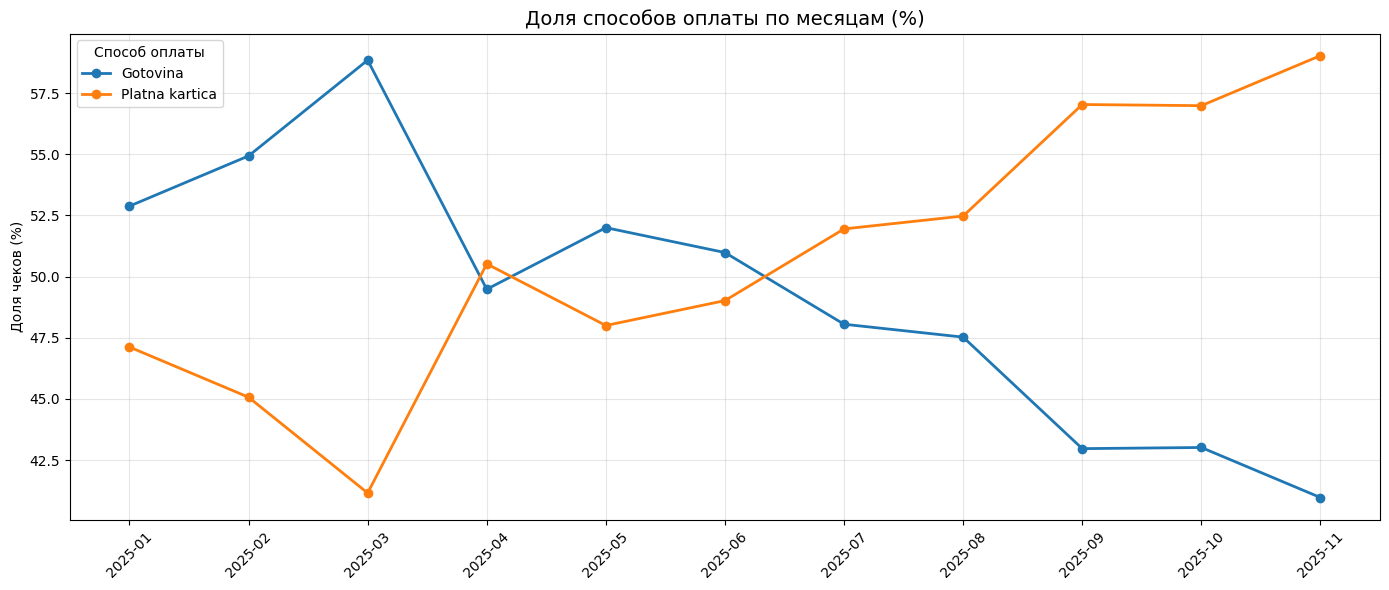

In [96]:
payment_share = payment_pivot.div(payment_pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(14, 6))

for method in payment_share.columns:
    plt.plot(
        payment_share.index,
        payment_share[method],
        marker='o',
        linewidth=2,
        label=method
    )

plt.title("Доля способов оплаты по месяцам (%)", fontsize=14)
plt.ylabel("Доля чеков (%)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend(title="Способ оплаты")
plt.tight_layout()
plt.show()

### Динамика продаж спешалти и не спешалти напитков по месяцам (только по кофейным группам)

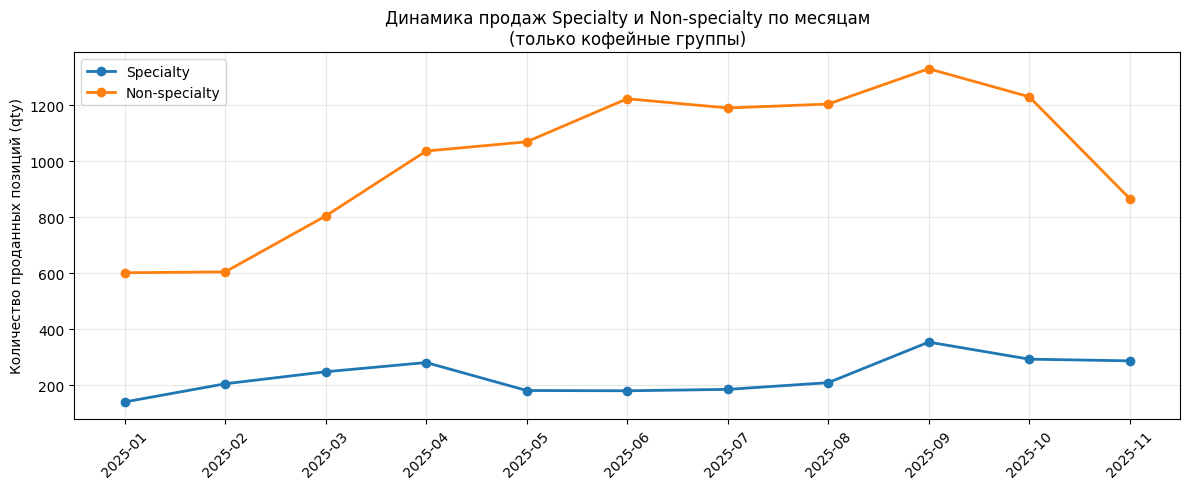

In [97]:
coffee_groups = [
    'Espresso Freddo', 'Filter Batch Brew', 'Flat white', 'V60',
    'Americano', 'Cappuccino', 'Coffee drinks', 'Espresso Specialty',
    'Cappuccino Specialty', 'Latte', 'Espresso',
    'Americano Specialty', 'Flat white Specialty', 'Spanish Iced Latte',
    'Latte Specialty', 'Aeropress', 'Beans', 'Bumble',
    'Non-alcohol Coffee Cocktails', 'Bumble Specialty', 'V60 Iced',
    'Cappuccino Freddo', 'Iced Americano', 'Iced Latte', 'Portional V60',
    'Drip coffee', 'Cold brew tonic', 'Iced Latte Specialty',
    'Flat white Freddo', 'Flat white Freddo Specialty',
    'Cappuccino Freddo Specialty', 'Cold brew',
    'Iced Americano Specialty', 'Hand Brew', 'Switch'
]

# фильтруем нужные группы
positions_f = positions[positions['group'].isin(coffee_groups)].copy()

# месяц
positions_f['month'] = positions_f['datetime'].dt.to_period('M')

# агрегация: месяц × specialty
specialty_monthly = (
    positions_f
    .groupby(['month', 'specialty'])['qty']
    .sum()
    .reset_index()
)

# pivot
specialty_pivot = specialty_monthly.pivot(
    index='month',
    columns='specialty',
    values='qty'
).fillna(0)

specialty_pivot.index = specialty_pivot.index.astype(str)

plt.figure(figsize=(12, 5))

plt.plot(
    specialty_pivot.index,
    specialty_pivot.get(True, 0),
    marker='o',
    linewidth=2,
    label='Specialty'
)

plt.plot(
    specialty_pivot.index,
    specialty_pivot.get(False, 0),
    marker='o',
    linewidth=2,
    label='Non-specialty'
)

plt.title("Динамика продаж Specialty и Non-specialty по месяцам\n(только кофейные группы)")
plt.ylabel("Количество проданных позиций (qty)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Динамика продаж по типу молока

In [98]:
def plot_monthly_qty_by_category(df, category_col, title, top_n=None, fillna_value=None):
    """
    category_col: категориальная колонка (например 'type_of_milk' или 'size')
    top_n: если категорий много — оставить только top_n по суммарному qty
    fillna_value: чем заменить NaN (например 'Unknown')
    """

    tmp = df.copy()

    if fillna_value is not None:
        tmp[category_col] = tmp[category_col].fillna(fillna_value)

    # агрегируем qty по месяцам и категории
    agg = (
        tmp.groupby(['month', category_col])['qty']
        .sum()
        .reset_index()
    )

    pivot = agg.pivot(index='month', columns=category_col, values='qty').fillna(0)

    # если много категорий — ограничим top_n
    if top_n is not None and pivot.shape[1] > top_n:
        top_cols = pivot.sum(axis=0).sort_values(ascending=False).head(top_n).index
        pivot = pivot[top_cols]

    # строим
    plt.figure(figsize=(14, 6))
    for col in pivot.columns:
        plt.plot(pivot.index, pivot[col], marker='o', linewidth=2, label=str(col))

    plt.title(title, fontsize=14)
    plt.ylabel("Количество проданных позиций (qty)")
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.legend(title=category_col)
    plt.tight_layout()
    plt.show()

    return pivot

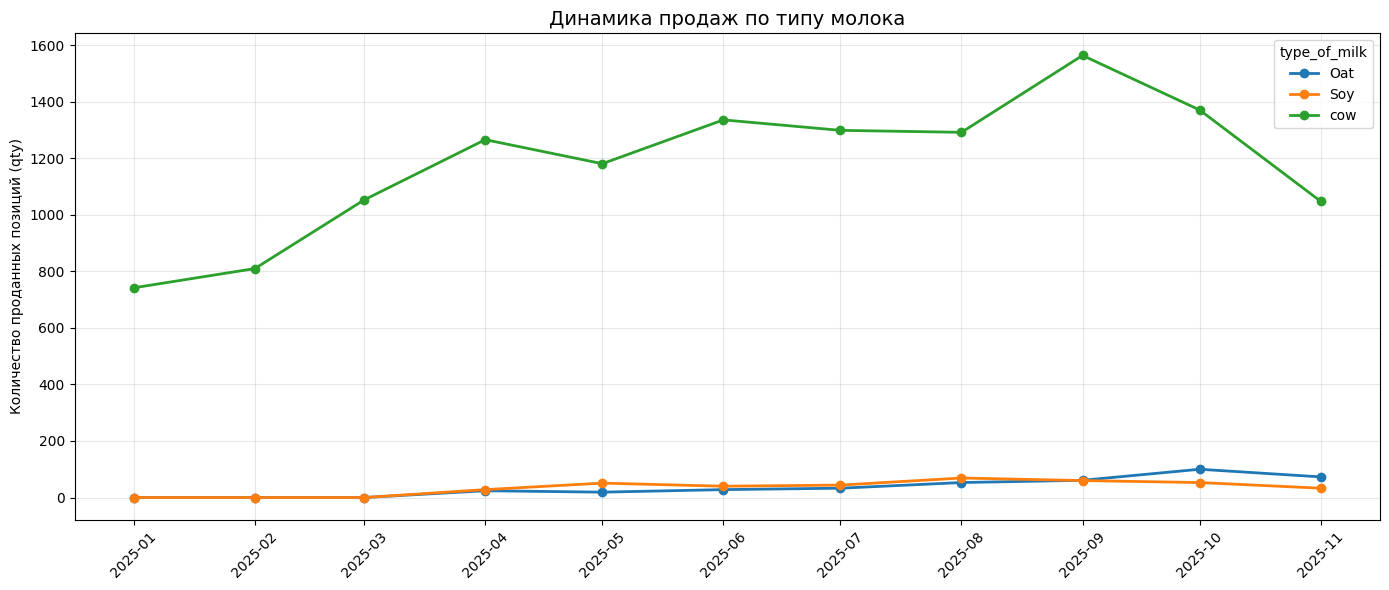

In [99]:
positions_f['month'] = (
    positions_f['datetime']
    .dt.to_period('M')
    .dt.to_timestamp()
)

milk_pivot = plot_monthly_qty_by_category(
    positions_f,
    category_col='type_of_milk',
    title="Динамика продаж по типу молока",
    top_n=10,
    fillna_value='Unknown'
)

### Динамика продаж по размеру напитка

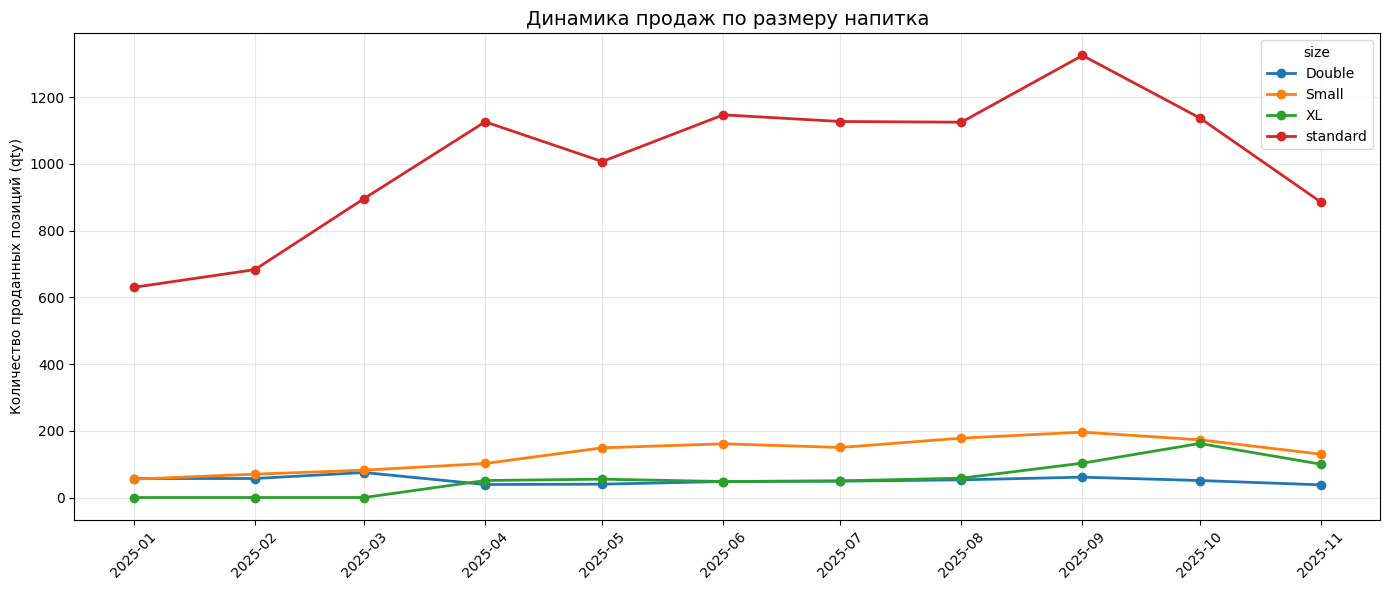

In [100]:
size_pivot = plot_monthly_qty_by_category(
    positions_f,
    category_col='size',
    title="Динамика продаж по размеру напитка",
    top_n=10,
    fillna_value='Unknown'
)

## Топ-20 пар "что берут вместе"

In [101]:
# чистим данные
df = positions[['check_number', 'name', 'qty']].copy()
df = df.dropna(subset=['check_number', 'name'])
df['name'] = df['name'].astype(str).str.strip()

# собираем набор позиций по каждому чеку (presence: 1 позиция = 1, qty игнорируем)
basket = (
    df.groupby('check_number')['name']
    .apply(lambda s: sorted(set(s)))   # set, чтобы не дублировать позиции внутри чека
)

# считаем пары
pair_counts = Counter()
for items in basket:
    if len(items) < 2:
        continue
    pair_counts.update(combinations(items, 2))

top_pairs = pd.DataFrame(pair_counts.most_common(20), columns=['pair', 'checks_together'])
top_pairs[['item_A', 'item_B']] = pd.DataFrame(top_pairs['pair'].tolist(), index=top_pairs.index)
top_pairs = top_pairs.drop(columns=['pair'])

top_pairs

,checks_together,item_A,item_B
0,126,Cappuccino,Espresso
1,126,Cappuccino,Mali Cappuccino
2,123,Espresso,Mali Cappuccino
3,122,Flat white,Latte
4,118,Cappuccino,Oreški
5,113,Cappuccino,Latte
6,81,Latte,Oreški
7,79,Americano,Cappuccino
8,73,Cappuccino,Zova
9,70,Cappuccino,Narandza
